# Problem Statement

Task 1:-Prepare a complete data analysis report on the given data.
Task 2:-Create a predictive model which will help theTexas state government
team to know the payroll information of employees of the state of Texas.
Task 3:-
● Who are the outliers in the salaries?
● What departments/roles have the biggest wage disparities between
managers and employees?
● Have salaries and total compensations for some roles/ departments/
head-count changed over time?

###  Import Libraries

In [1]:
!pip install numpy
!pip install pandas
!pip install seaborn

  Using cached matplotlib-3.11.0-cp311-cp311-win_amd64.whl.metadata (80 kB)
Using cached matplotlib-3.11.0-cp311-cp311-win_amd64.whl (9.3 MB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires visions[type_image_path]==0.7.4, but you have visions 0.8.1 which is incompatible.


In [2]:
!pip install matplotlib

In [1]:
# 'Numpy' is used for mathematical operations on large, multi-dimensional arrays and matrices
import numpy as np

# 'Pandas' is used for data manipulation and analysis
import pandas as pd

# 'Seaborn' is based on matplotlib; used for plotting statistical graphics
import seaborn as sns

# 'Matplotlib' is a data visualization library for 2D and 3D plots, built on numpy
import matplotlib.pyplot as plt
%matplotlib inline 


# suppress display of warnings
import warnings
warnings.filterwarnings('ignore')


### Importing data

In [2]:
data=pd.read_csv('salary.csv')

### Checking dataset using Autoviz library

In [5]:
pip install autoviz

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.1
    Uninstalling joblib-1.1.1:
      Successfully uninstalled joblib-1.1.1
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.5.3 which is incompatible.
pandas-profiling 3.2.0 requires visions[type_image_path]==0.7.4, but you have visions 0.8.1 which is incompatible.


In [3]:
from autoviz.AutoViz_Class import AutoViz_Class

Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)


In [4]:
# Solution 1: Install and use AutoViz (corrected installation)
# !pip install autoviz==0.1.58  # Use a specific version that's compatible

# If AutoViz still has compatibility issues, use Solution 2 below

# Solution 2: Use modern visualization libraries (recommended approach)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
df = pd.read_csv('salary.csv')

# Create comprehensive visualizations manually
# 1. Distribution of target variable
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.histplot(data=df, x='ANNUAL', kde=True)
plt.title('Distribution of Annual Salary')

# 2. Correlation matrix for numeric columns
plt.subplot(2, 3, 2)
numeric_cols = df.select_dtypes(include=['number']).columns
if len(numeric_cols) > 1:
    correlation_matrix = df[numeric_cols].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Correlation Matrix')

# 3. Box plot for categorical vs target (if categorical columns exist)
categorical_cols = df.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    plt.subplot(2, 3, 3)
    # Use the first categorical column as example
    sns.boxplot(data=df, x=categorical_cols[0], y='ANNUAL')
    plt.title(f'Annual Salary by {categorical_cols[0]}')
    plt.xticks(rotation=45)

# 4. Scatter plot for numeric variables
if len(numeric_cols) > 2:
    plt.subplot(2, 3, 4)
    # Create scatter plot with first two numeric columns (excluding target)
    other_numeric = [col for col in numeric_cols if col != 'ANNUAL']
    if len(other_numeric) >= 1:
        sns.scatterplot(data=df, x=other_numeric[0], y='ANNUAL', alpha=0.6)
        plt.title(f'Annual Salary vs {other_numeric[0]}')

# 5. Summary statistics
plt.subplot(2, 3, 5)
plt.text(0.1, 0.9, f"Dataset Shape: {df.shape}", transform=plt.gca().transAxes, fontsize=12)
plt.text(0.1, 0.8, f"Missing Values: {df.isnull().sum().sum()}", transform=plt.gca().transAxes, fontsize=12)
plt.text(0.1, 0.7, f"Numeric Columns: {len(numeric_cols)}", transform=plt.gca().transAxes, fontsize=12)
plt.text(0.1, 0.6, f"Categorical Columns: {len(categorical_cols)}", transform=plt.gca().transAxes, fontsize=12)
plt.title('Dataset Summary')
plt.axis('off')

# 6. Missing values heatmap
plt.subplot(2, 3, 6)
if df.isnull().sum().sum() > 0:
    sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
    plt.title('Missing Values Pattern')
else:
    plt.text(0.5, 0.5, 'No Missing Values', ha='center', va='center', transform=plt.gca().transAxes, fontsize=14)
    plt.title('Missing Values Check')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Additional: Pairplot for comprehensive analysis (only if manageable number of columns)
if len(numeric_cols) <= 5 and len(numeric_cols) > 1:
    plt.figure(figsize=(12, 10))
    sns.pairplot(df[numeric_cols])
    plt.suptitle('Pairplot of Numeric Variables', y=1.02)
    plt.show()

# Display basic info about the dataset
print("Dataset Info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())
print(f"\nTarget variable (ANNUAL) statistics:")
print(df['ANNUAL'].describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149481 entries, 0 to 149480
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   AGENCY                   149481 non-null  int64  
 1   AGENCY NAME              149481 non-null  object 
 2   LAST NAME                149481 non-null  object 
 3   FIRST NAME               149481 non-null  object 
 4   MI                       149481 non-null  object 
 5   CLASS CODE               149481 non-null  object 
 6   CLASS TITLE              149481 non-null  object 
 7   ETHNICITY                149481 non-null  object 
 8   GENDER                   149481 non-null  object 
 9   STATUS                   149481 non-null  object 
 10  EMPLOY DATE              149481 non-null  object 
 11  HRLY RATE                149481 non-null  float64
 12  HRS PER WK               149481 non-null  float64
 13  MONTHLY                  149481 non-null  flo

### Insights

1- It is clearly visible that employees with CRF(Classified regular full time) status earn more compare to other categories in status for both male and female [gender category].

2- Full time employees are getting more annual wages compared to part time employees.

3- Classified Regular Full time employees are earning more as compared to classified temporary full time.

4- Agency wise highest earning agency is Board of architectural examiners.


5- Agency no.-105 only have Hispanic workers ethinicity wise.

6- White ethnicity have maxiumum HRLY RATE on the other hand black ethnicity has least.

### Dataframe profile

In [8]:
pip install pandas-profiling

  Using cached joblib-1.1.1-py2.py3-none-any.whl.metadata (5.2 kB)
  Using cached visions-0.7.4-py3-none-any.whl.metadata (5.9 kB)
Using cached visions-0.7.4-py3-none-any.whl (102 kB)
Using cached joblib-1.1.1-py2.py3-none-any.whl (309 kB)

  Attempting uninstall: joblib

    Found existing installation: joblib 1.5.3

    Uninstalling joblib-1.5.3:

      Successfully uninstalled joblib-1.5.3

   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-learn 1.9.0 requires joblib>=1.4.0, but you have joblib 1.1.1 which is incompatible.


In [9]:
pip install ydata_profiling

  Using cached ydata_profiling-4.18.4-py2.py3-none-any.whl.metadata (23 kB)
  Using cached matplotlib-3.10.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached visions-0.8.1-py3-none-any.whl.metadata (11 kB)
Using cached ydata_profiling-4.18.4-py2.py3-none-any.whl (400 kB)
Using cached matplotlib-3.10.0-cp311-cp311-win_amd64.whl (8.0 MB)
Using cached visions-0.8.1-py3-none-any.whl (105 kB)

  Attempting uninstall: matplotlib

    Found existing installation: matplotlib 3.11.0

    Uninstalling matplotlib-3.11.0:

   ---------------------------------------- 0/3 [matplotlib]
   ---------------------------------------- 0/3 [matplotlib]
   ---------------------------------------- 0/3 [matplotlib]
   ---------------------------------------- 0/3 [matplotlib]
   ---------------------------------------- 0/3 [matplotlib]
   ---------------------------------------- 0/3 [matplotlib]
   ---------------------------------------- 0/3 [matplotlib]
   ---------------------------------------- 0/3

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\users\\user\\.conda\\envs\\pythonproject\\lib\\site-packages\\matplotlib\\backends\\_backend_agg.cp311-win_amd64.pyd'
Consider using the `--user` option or check the permissions.



In [5]:
# Try multiple installation methods to ensure the package is properly installed

# Method 1: Install using conda (recommended for Anaconda/Miniconda users)
#  !conda install -c conda-forge ydata-profiling -y

# Method 2: If conda fails, try pip with --user flag
!pip install --user ydata-profiling

# Method 3: Alternative package name (older versions)
# !pip install pandas-profiling

# Method 4: Force reinstall if package exists but import fails
# !pip install --upgrade --force-reinstall ydata-profiling

# After installation, restart the kernel (Kernel -> Restart) then try importing
from ydata_profiling import ProfileReport

# Alternative import for older versions of the package
# from pandas_profiling import ProfileReport

In [6]:
df=pd.read_csv('salary.csv')
Profile=ProfileReport(df, title= "Texas Employees salary prediction", html={'style':{'full_width':True}})

In [7]:
Profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|          | 0/21 [00:00<?, ?it/s]
%|▉         | 2/21 [00:09<01:31,  4.80s/it]
%|█▍        | 3/21 [00:10<00:56,  3.15s/it]
%|█▉        | 4/21 [00:10<00:35,  2.06s/it]
%|██▍       | 5/21 [00:10<00:22,  1.40s/it]
%|██▊       | 6/21 [00:11<00:15,  1.02s/it]
%|███▎      | 7/21 [00:11<00:10,  1.37it/s]
%|███▊      | 8/21 [00:11<00:07,  1.73it/s]
%|████▎     | 9/21 [00:11<00:05,  2.03it/s]
%|████▊     | 10/21 [00:12<00:04,  2.55it/s]
100%|██████████| 21/21 [00:41<00:00,  1.96s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### Univariant Analysis

In [8]:
!pip install sweetviz

   ---------------------------------------- 0.0/15.1 MB ? eta -:--:--
    --------------------------------------- 0.3/15.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.1 MB 1.2 MB/s eta 0:00:13
   -- ------------------------------------- 0.8/15.1 MB 1.3 MB/s eta 0:00:12
   -- ------------------------------------- 1.0/15.1 MB 1.3 MB/s eta 0:00:11
   --- ------------------------------------ 1.3/15.1 MB 1.3 MB/s eta 0:00:11
   ---- ----------------------------------- 1.6/15.1 MB 1.3 MB/s eta 0:00:11
   ----- ---------------------------------- 2.1/15.1 MB 1.3 MB/s eta 0:00:11
   ------ --------------------------------- 2.4/15.1 MB 1.3 MB/s eta 0:00:10
   ------ --------------------------------- 2.6/15.1 MB 1.3 MB/s eta 0:00:10
   ------- -------------------------------- 2.9/15.1 MB 1.3 MB/s eta 0:00:10
   -------- ------------------------------- 3.1/15.1 MB 1.3 MB/s eta 0:00:10
   --------- ------------------------------ 3.4/15.1 MB 1.3 MB/s eta 0:00:10
   --------- 

                                             |          | [  0%]   00:00 -> (? left)


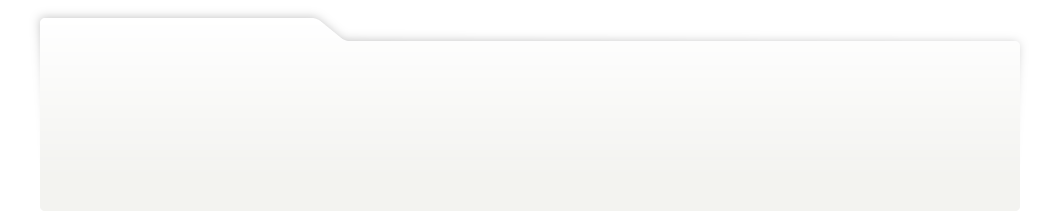
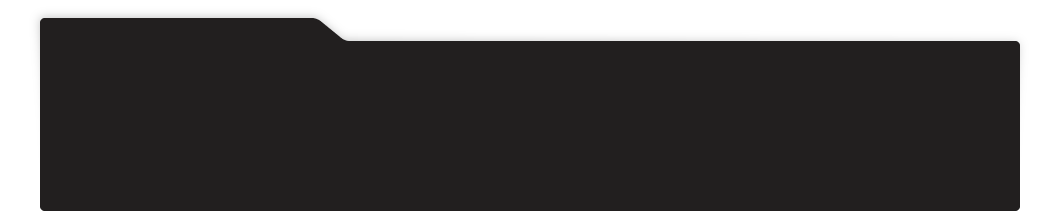
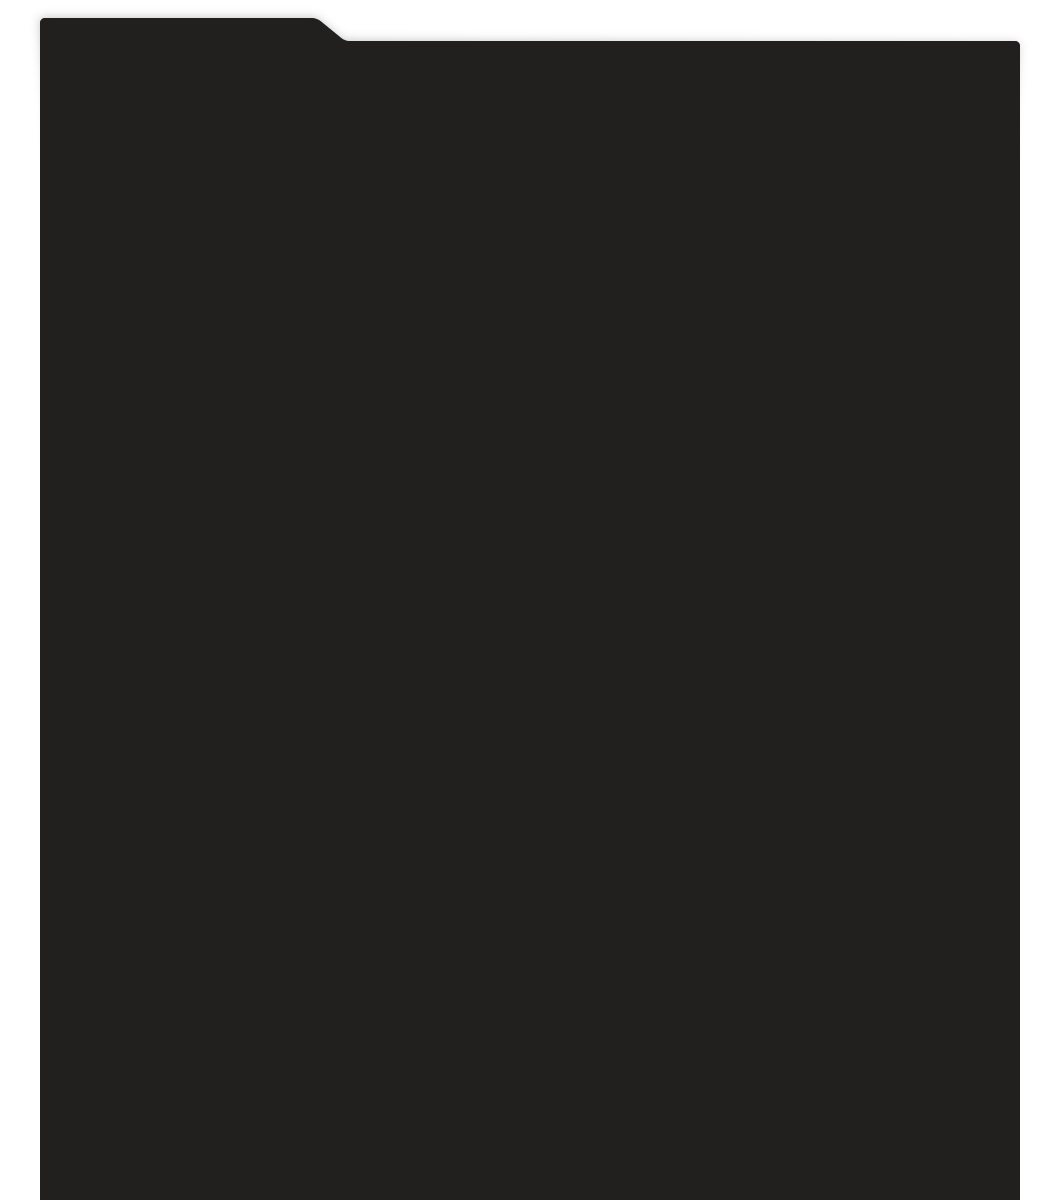
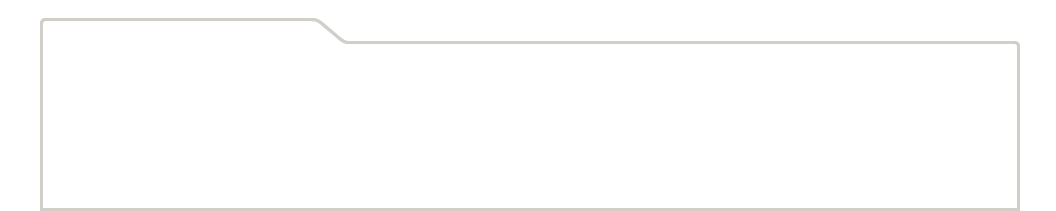
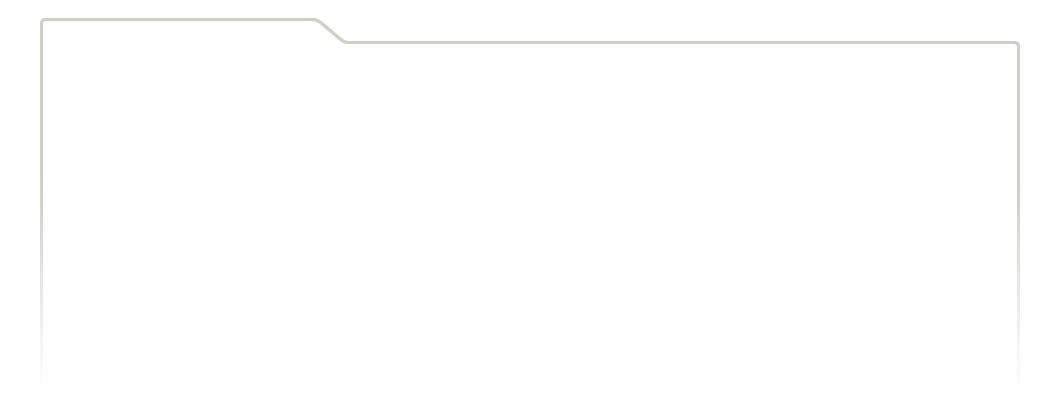
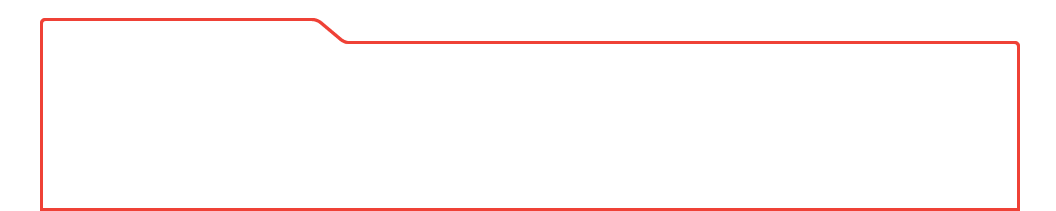
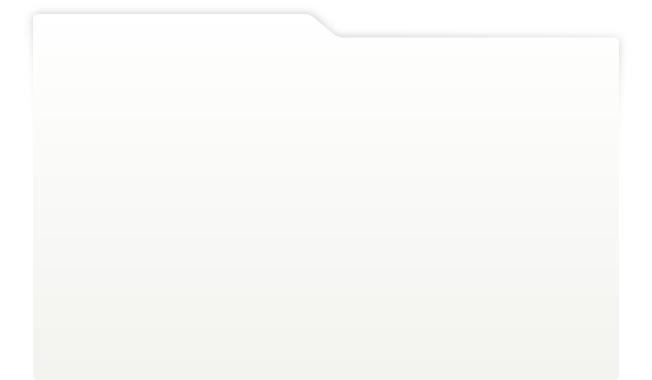
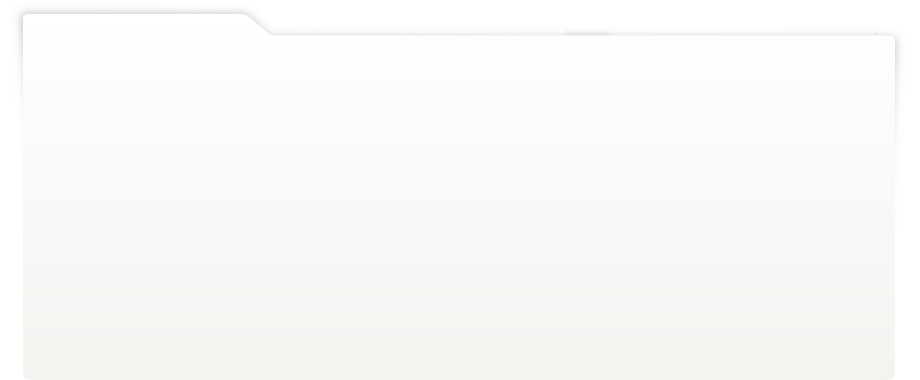
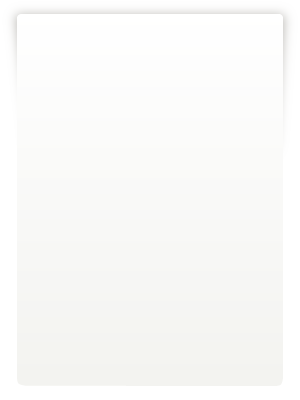
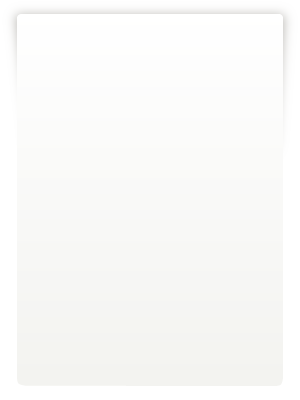
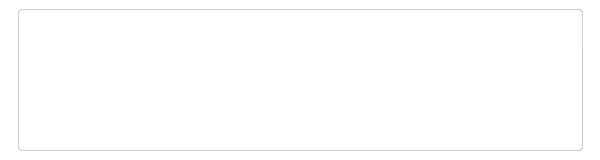
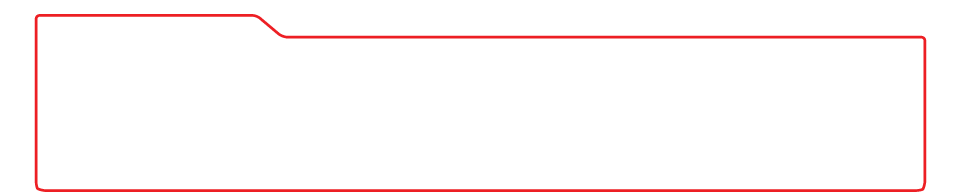
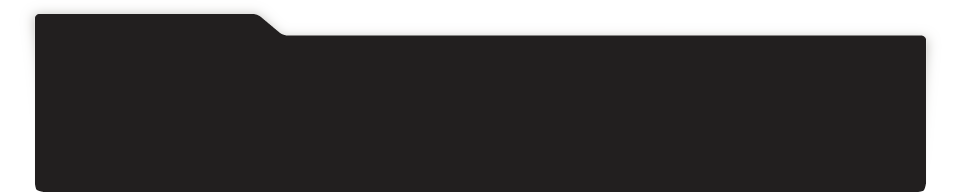
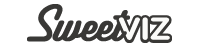
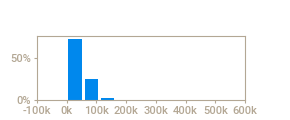
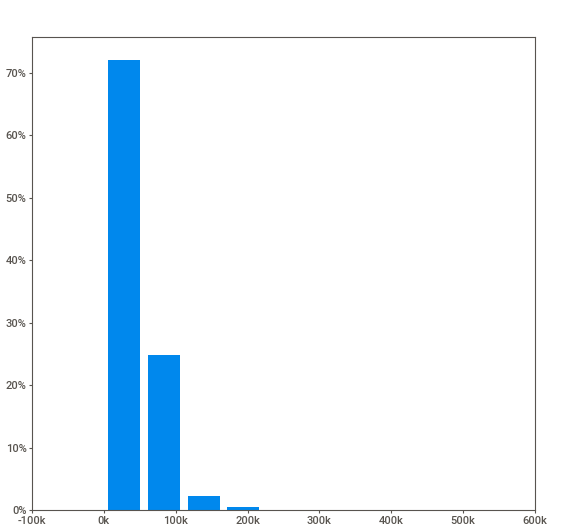
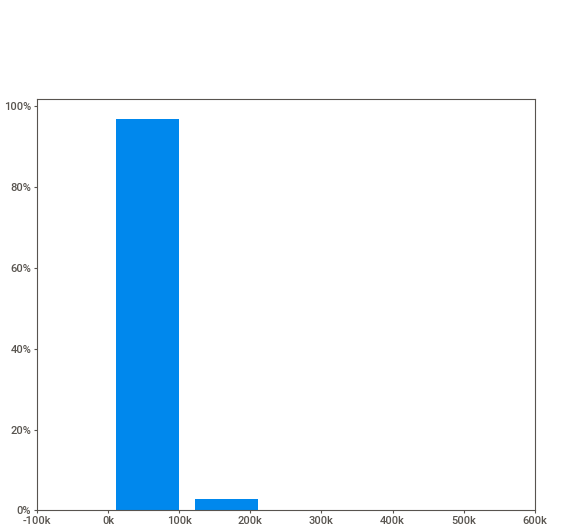
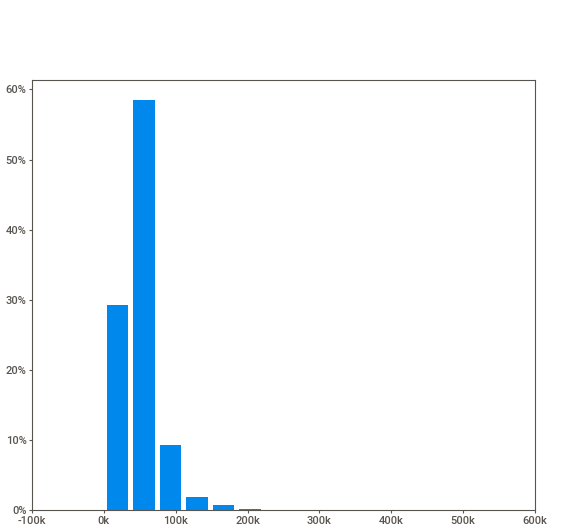
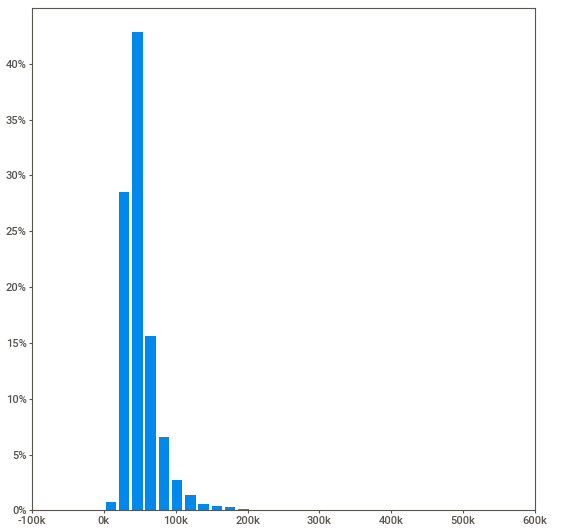
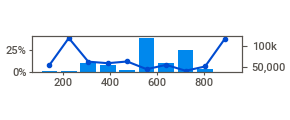
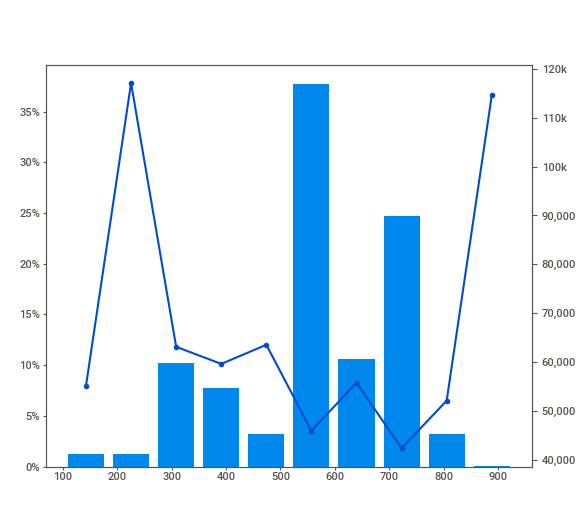
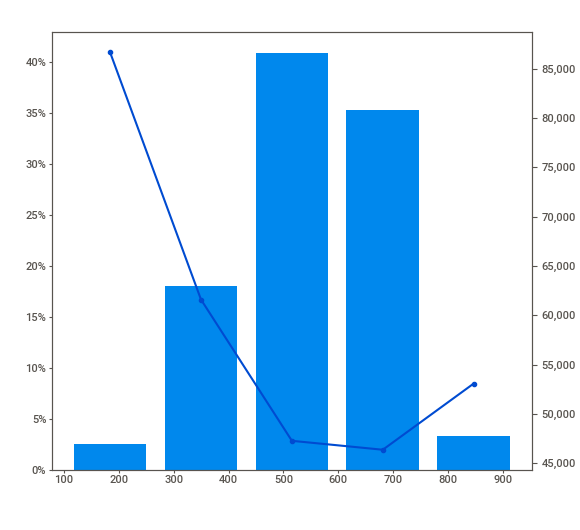
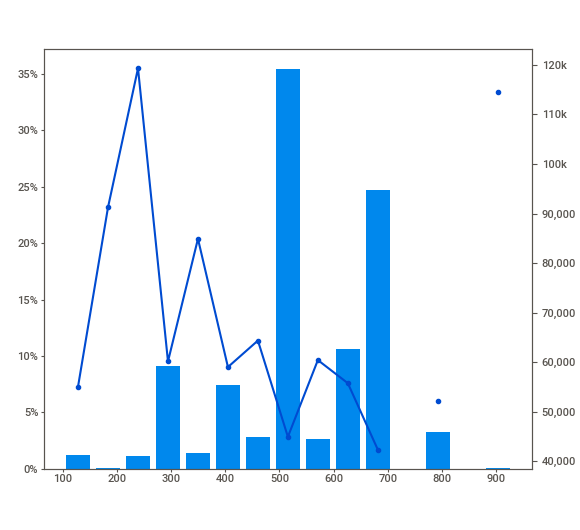
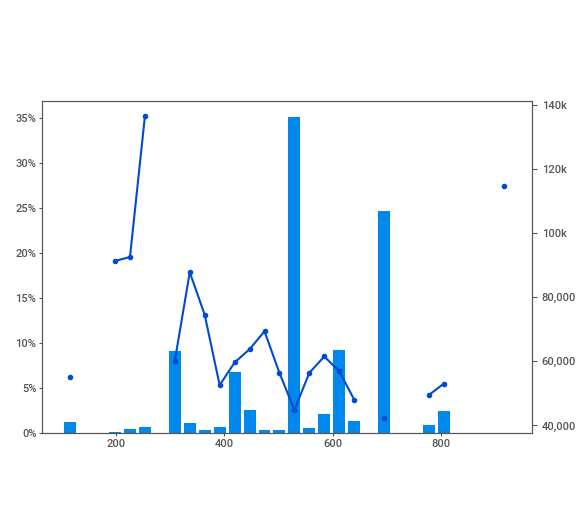
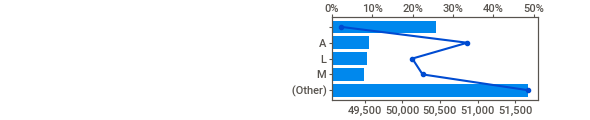
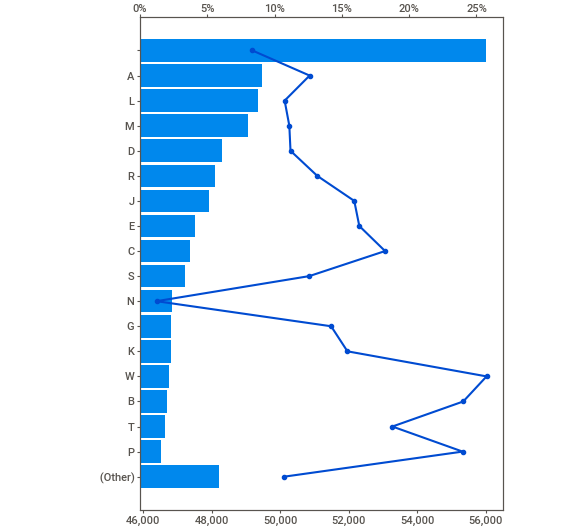
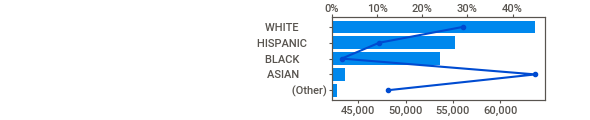
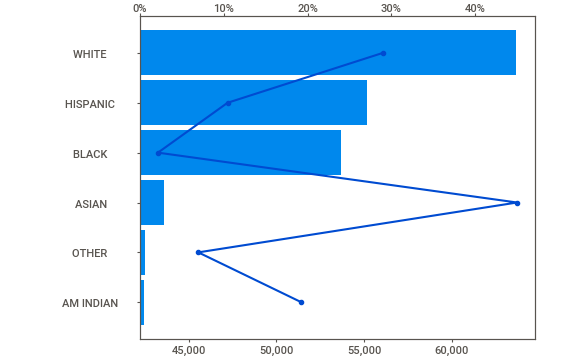
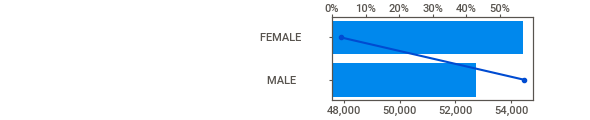
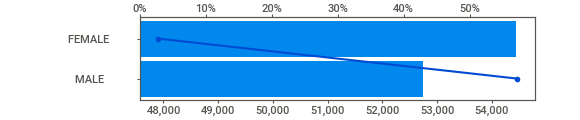
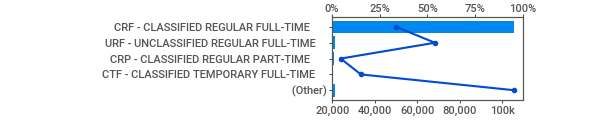
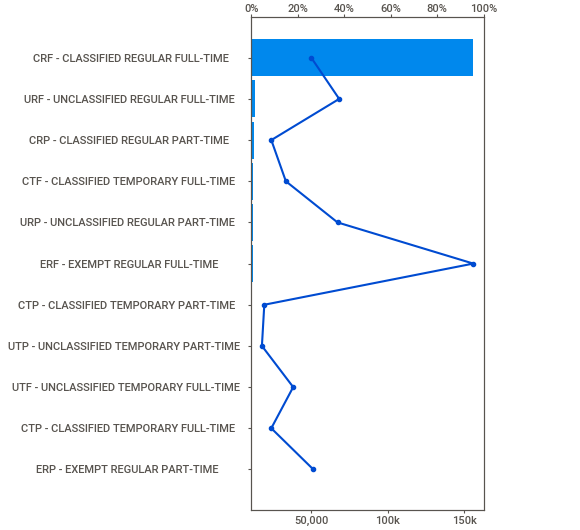
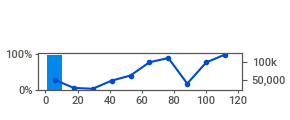
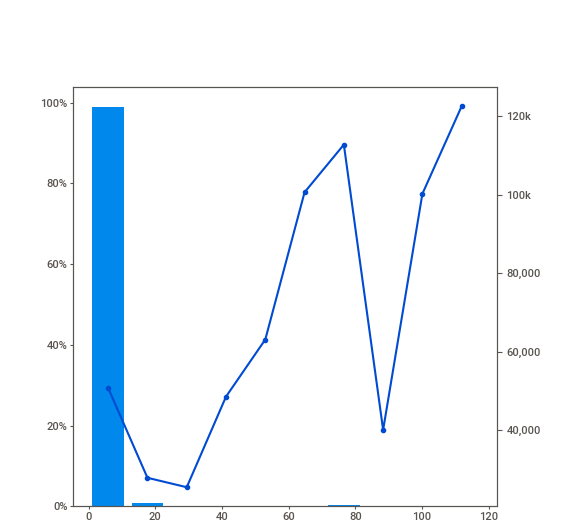
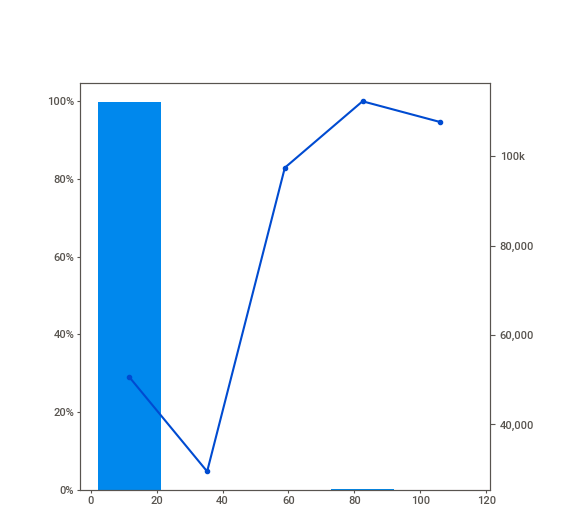
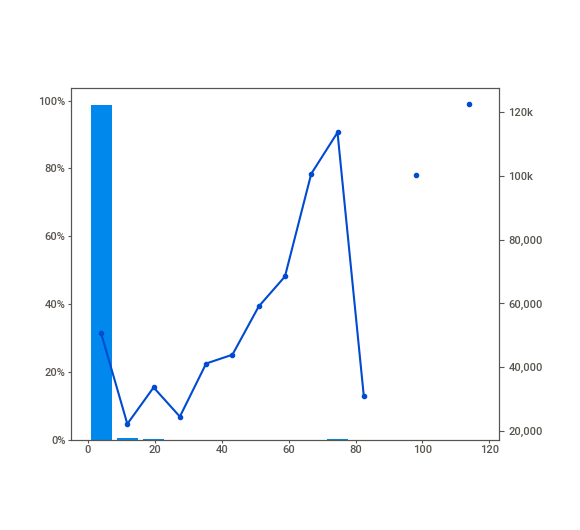
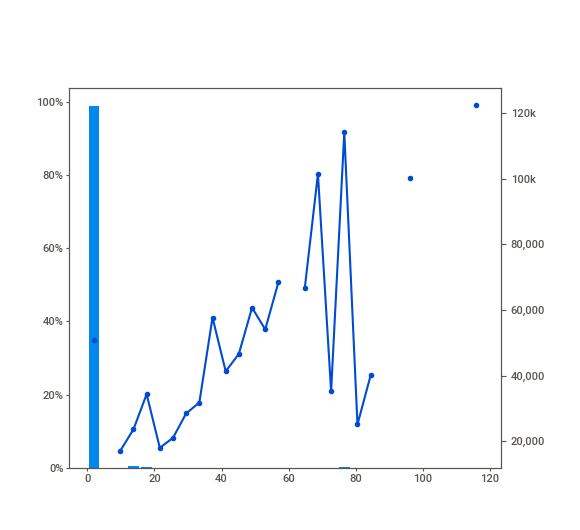
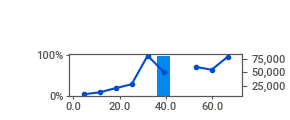
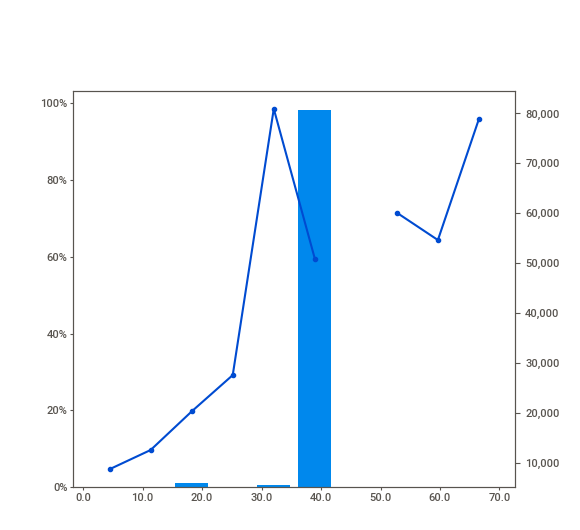
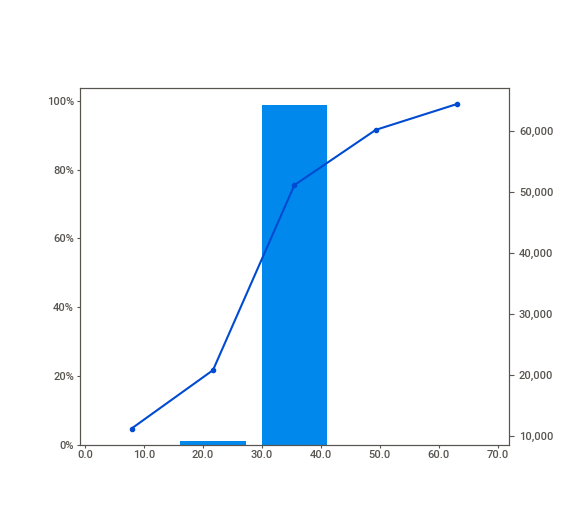
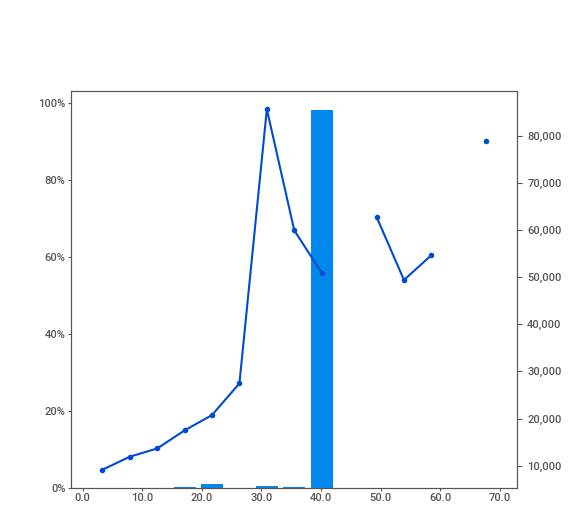
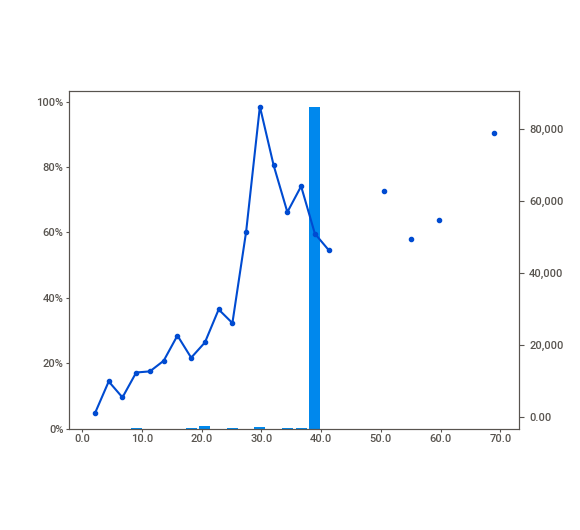
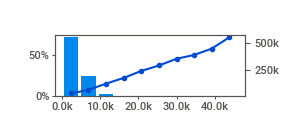
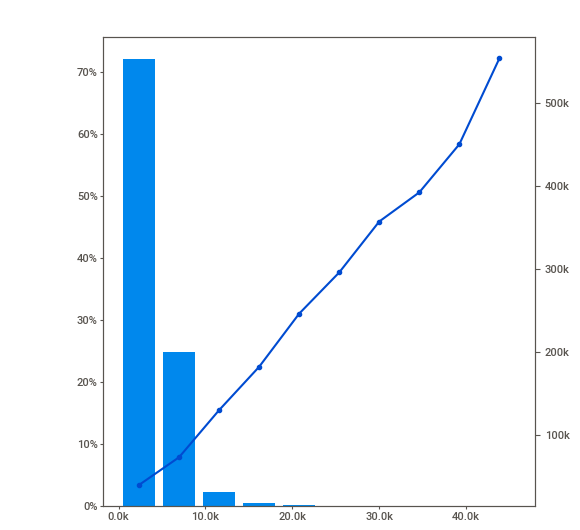
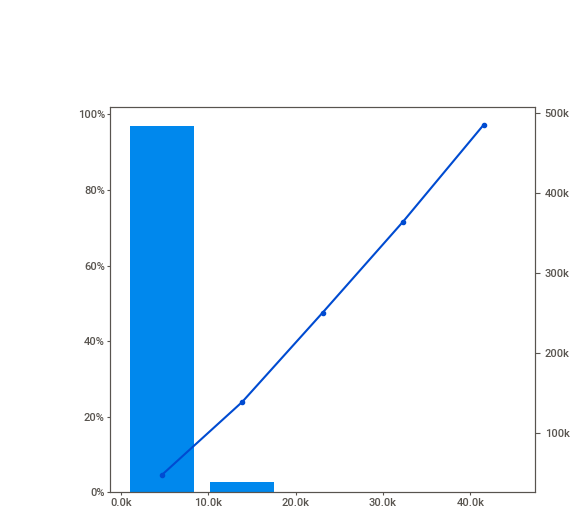
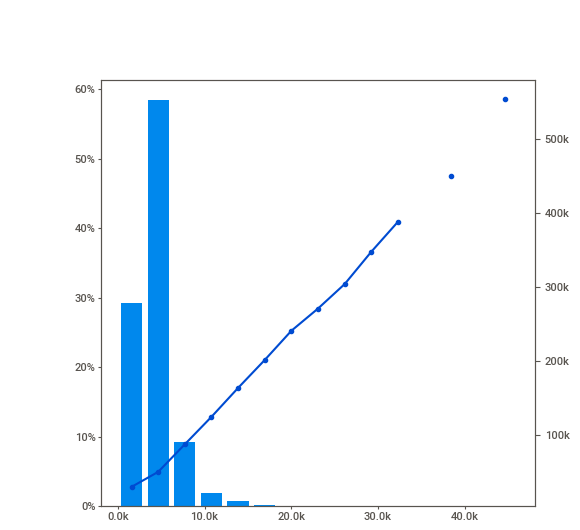
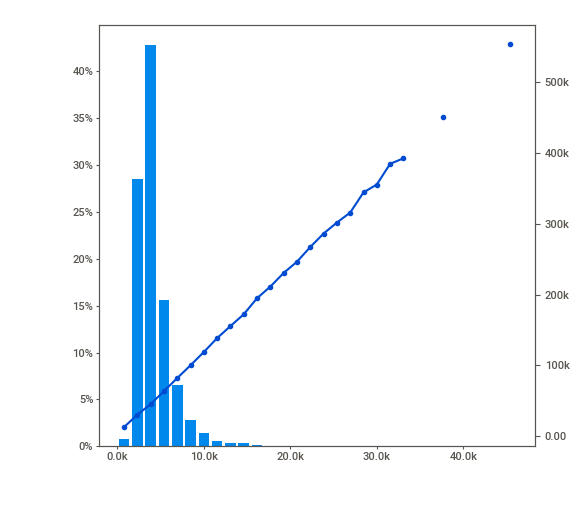
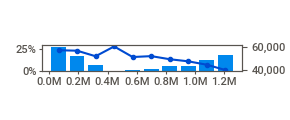
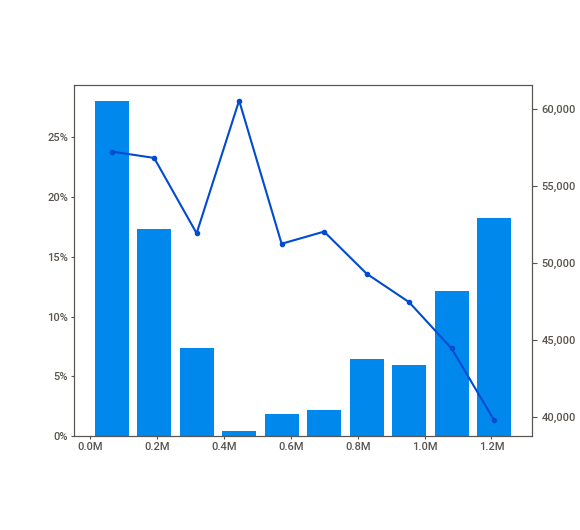
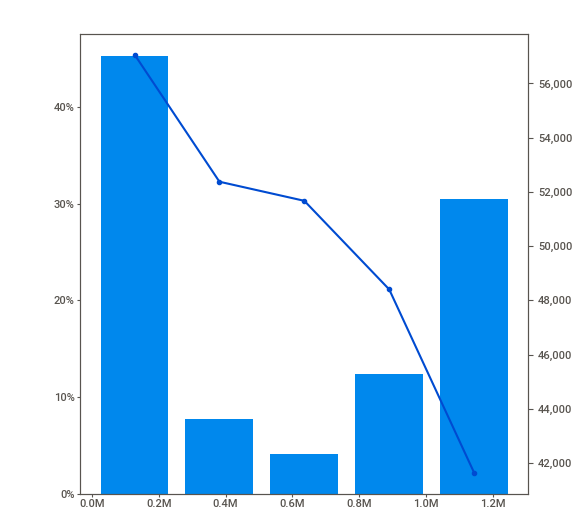
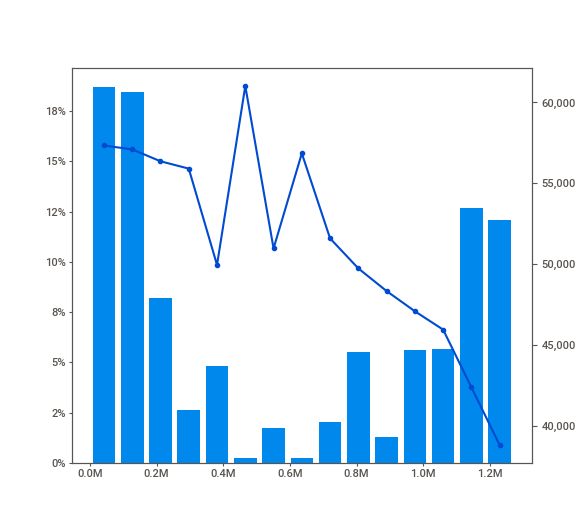
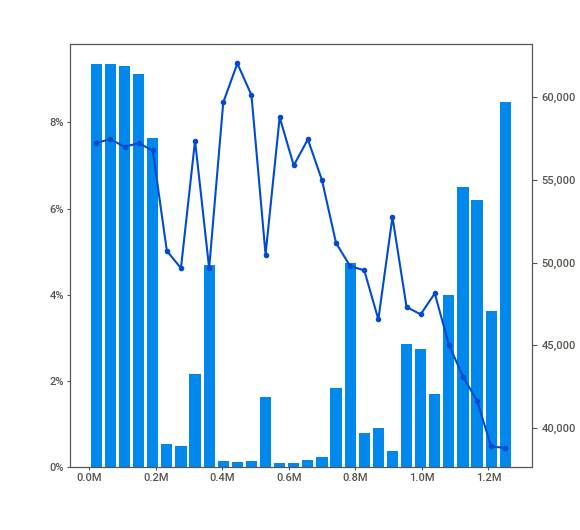
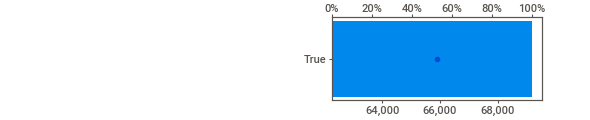
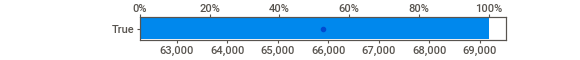
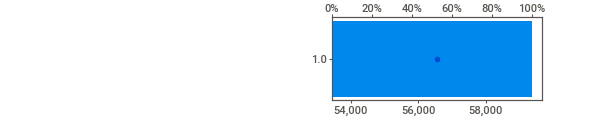
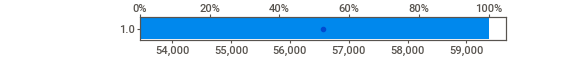
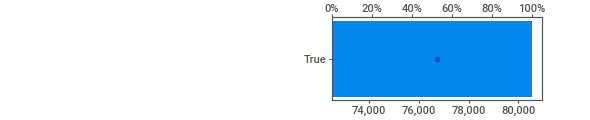
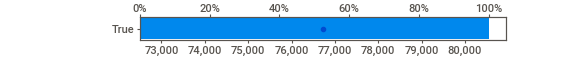
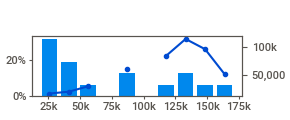
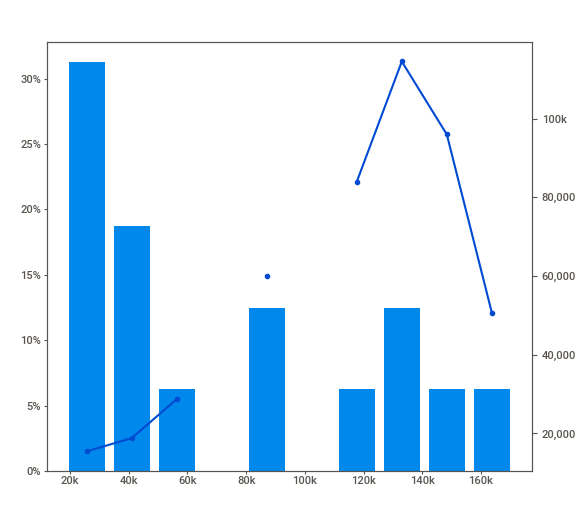
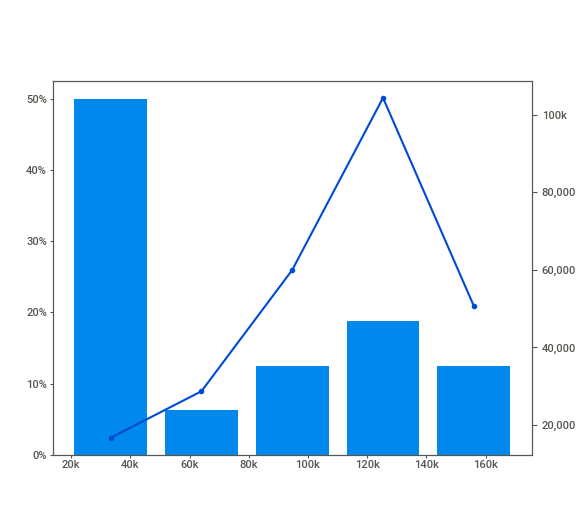
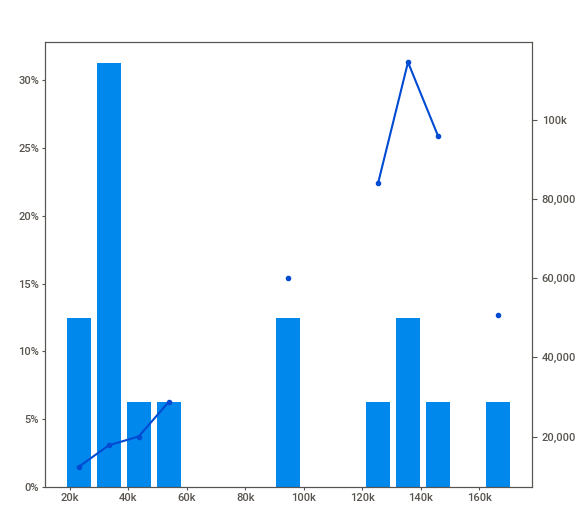
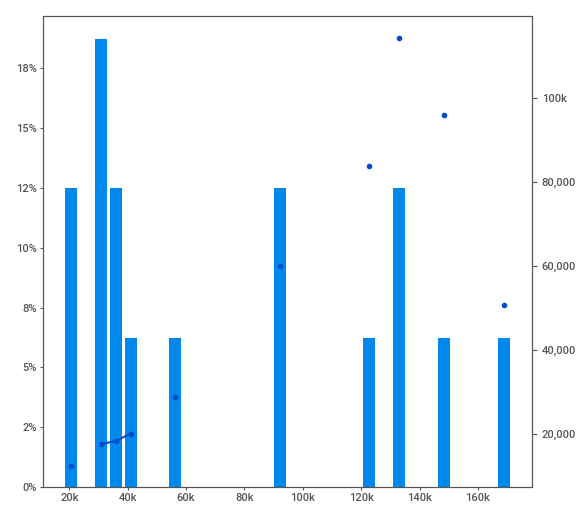
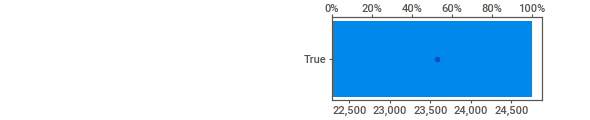
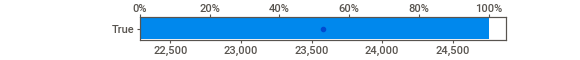
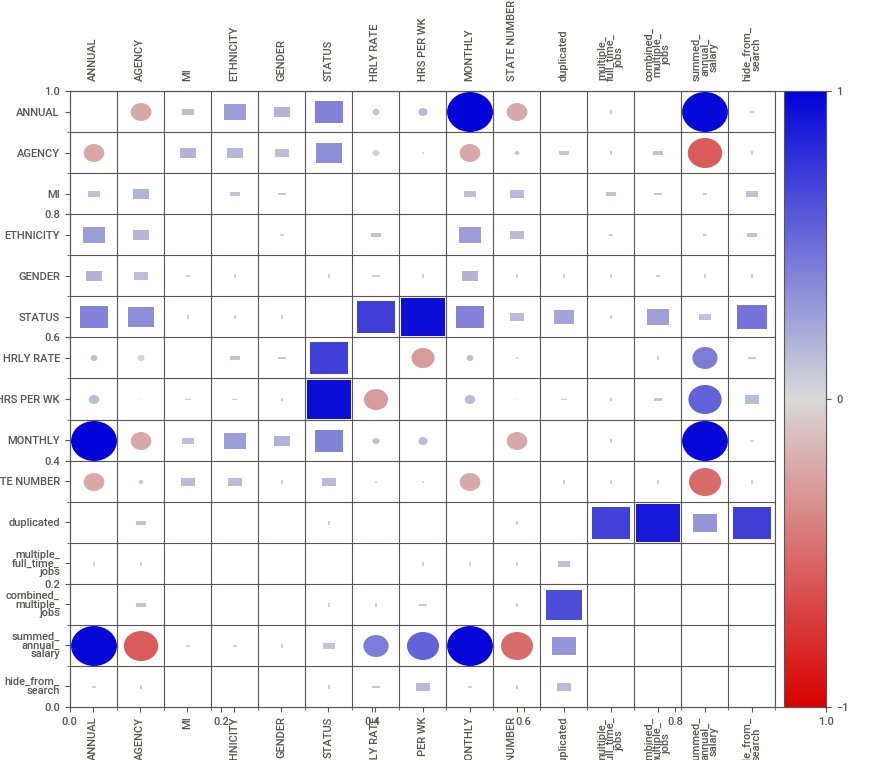
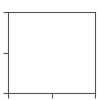

In [9]:
import sweetviz as sv#importing sweetviz library 
df_sv=pd.read_csv('salary.csv')
my_report = sv.analyze(df_sv, target_feat= 'ANNUAL')#syntax to use sweetviz
my_report.show_notebook(w=880,h=700,layout='vertical', scale=0.8)

### Exploratory Data Analysis

In [10]:
data.head()

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECTION",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02/01/15,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECTION",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/01/20,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09/01/18,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN


## Summary Statistics

In [11]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
AGENCY,149481.0,545.736288,139.057691,101.0,529.00,530.00,696.00,9.300000e+02
HRLY RATE,149481.0,0.346488,4.211485,0.0,0.00,0.00,0.00,1.177885e+02
HRS PER WK,149481.0,39.714918,2.323855,1.0,40.00,40.00,40.00,7.000000e+01
MONTHLY,149481.0,4226.184248,2093.111691,50.0,3019.84,3720.17,4865.81,4.612500e+04
ANNUAL,149481.0,50714.210973,25117.340292,600.0,36238.08,44642.04,58389.72,5.535000e+05
STATE NUMBER,149481.0,565193.023521,478621.220542,1.0,113334.00,346373.00,1100500.00,1.271604e+06
multiple_full_time_jobs,14.0,1.000000,0.000000,1.0,1.00,1.00,1.00,1.000000e+00
summed_annual_salary,16.0,74303.955000,51925.944282,18000.0,32962.50,48063.30,123751.77,1.713834e+05


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149481 entries, 0 to 149480
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   AGENCY                   149481 non-null  int64  
 1   AGENCY NAME              149481 non-null  object 
 2   LAST NAME                149481 non-null  object 
 3   FIRST NAME               149481 non-null  object 
 4   MI                       149481 non-null  object 
 5   CLASS CODE               149481 non-null  object 
 6   CLASS TITLE              149481 non-null  object 
 7   ETHNICITY                149481 non-null  object 
 8   GENDER                   149481 non-null  object 
 9   STATUS                   149481 non-null  object 
 10  EMPLOY DATE              149481 non-null  object 
 11  HRLY RATE                149481 non-null  float64
 12  HRS PER WK               149481 non-null  float64
 13  MONTHLY                  149481 non-null  float64
 14  ANNU

In [13]:
data.isnull().sum()/ len(data)*100

AGENCY                      0.000000
AGENCY NAME                 0.000000
LAST NAME                   0.000000
FIRST NAME                  0.000000
MI                          0.000000
CLASS CODE                  0.000000
CLASS TITLE                 0.000000
ETHNICITY                   0.000000
GENDER                      0.000000
STATUS                      0.000000
EMPLOY DATE                 0.000000
HRLY RATE                   0.000000
HRS PER WK                  0.000000
MONTHLY                     0.000000
ANNUAL                      0.000000
STATE NUMBER                0.000000
duplicated                 99.904336
multiple_full_time_jobs    99.990634
combined_multiple_jobs     99.935109
summed_annual_salary       99.989296
hide_from_search           99.989296
dtype: float64

In [14]:
data.drop(['duplicated','multiple_full_time_jobs','combined_multiple_jobs','hide_from_search','summed_annual_salary','STATE NUMBER'], axis=1,inplace=True)

In [15]:
data.head()

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECTION",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84
1,212,OFFICE OF COURT ADMINISTRATION,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02/01/15,81.04454,4.0,1404.77,16857.24
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECTION",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/01/20,75.96150,29.0,9545.82,114549.84
3,212,OFFICE OF COURT ADMINISTRATION,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09/01/18,81.04453,4.0,1404.77,16857.24
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24


In [18]:
# Option 1: Select only numeric columns before calculating mean
# data.sort_values("ANNUAL", ascending=False).groupby(["AGENCY NAME","STATUS","CLASS TITLE"]).select_dtypes(include='number').mean()

# Option 2: Specify specific numeric columns you want to average
data.sort_values("ANNUAL", ascending=False).groupby(["AGENCY NAME","STATUS","CLASS TITLE"])["ANNUAL"].mean()

# Option 3: Use numeric_only parameter (if using pandas 1.5+)
# data.sort_values("ANNUAL", ascending=False).groupby(["AGENCY NAME","STATUS","CLASS TITLE"]).mean(numeric_only=True)

AGENCY NAME                                         STATUS                                    CLASS TITLE                                       
ALCOHOLIC BEVERAGE COMMISSION                       CRF - CLASSIFIED REGULAR FULL-TIME        ACCOUNTANT I                                           39263.52
                                                                                              ACCOUNTANT II                                          42500.04
                                                                                              ACCOUNTANT IV                                          51000.00
                                                                                              ACCOUNTANT VI                                          63543.48
                                                                                              ACCTS EXAM I                                           36000.00
                                                                 

### Analysis of Outliers

In [29]:
#accommodates  bathrooms  review_scores_rating  bedrooms  beds
fig, ax = plt.subplots(2,2, figsize= (15,18))
sns.boxplot(data['HRLY RATE'], ax= ax[0,0])
sns.boxplot(data['HRS PER WK'], ax= ax[0,1])
sns.boxplot(data['MONTHLY'], ax= ax[1,0])
sns.boxplot(data['ANNUAL'], ax= ax[1,1])
plt.show()

**Remove outliers by IQR method**

In [30]:
def find_boundaries(variable):
    
    q1 = data[variable].quantile(0.25)
    q3 = data[variable].quantile(0.75)
    iqr = q3 - q1
    lower_range = q1 - 1.5 * iqr #used to find the minimum value
    upper_range = q3 + 1.5 * iqr#max value
    return lower_range, upper_range

In [31]:
lower_ANNUAL, upper_ANNUAL = find_boundaries('ANNUAL')
print(lower_ANNUAL, upper_ANNUAL)

#capp the outlier / censoring the outlier
data.ANNUAL = np.where( data.ANNUAL > upper_ANNUAL, upper_ANNUAL, data.ANNUAL )
data.ANNUAL = np.where( data.ANNUAL < lower_ANNUAL, lower_ANNUAL, data.ANNUAL )

3010.6200000000026 91617.18


In [32]:
lower_MONTHLY, upper_MONTHLY = find_boundaries('MONTHLY')
print(lower_MONTHLY, upper_MONTHLY)

#capp the outlier / censoring the outlier
data.MONTHLY = np.where( data.MONTHLY > upper_MONTHLY, upper_MONTHLY, data.MONTHLY )
data.MONTHLY = np.where( data.MONTHLY < lower_MONTHLY, lower_MONTHLY, data.MONTHLY )

250.88499999999976 7634.765000000001


To confirm that the outliers have been removed; let us visualize the boxplot again.

### Plot the boxplot to recheck for outliers

In [33]:
fig, ax = plt.subplots(2,2, figsize= (15,18))
sns.boxplot(data['HRLY RATE'], ax= ax[0,0])
sns.boxplot(data['HRS PER WK'], ax= ax[0,1])
sns.boxplot(data['MONTHLY'], ax= ax[1,0])
sns.boxplot(data['ANNUAL'], ax= ax[1,1])
plt.show()

Observing the range of the boxplots, we say that the outliers are removed from the original data. The new 'outliers' that we can see in the variables are moderate outliers that lied within the upper whisker-lower whisker range before removing the original outliers. It can be seen that the variable `Monthly`& `Annual` has no new outliers.

It is up to the discretion of the data scientist, to remove them or not; and maybe decided after evaluating the model performance. 

A crude way to know whether the outliers have been removed or not is to check the dimensions of the data. If the dimension is reduced it implies that the outliers are removed.

In [34]:
data.shape

(149481, 15)

### Univariate Analysis

In [36]:
sns.displot(x=data.ANNUAL,kde=True)
plt.show()

In [37]:
sns.displot(x=data.MONTHLY,kde=True)
plt.show()

In [38]:
plt.figure(figsize=(20,20))
sns.scatterplot(x='AGENCY', y='ANNUAL', data=data, hue='STATUS')
plt.show()

In [39]:
plt.figure(figsize=(20,20))
sns.scatterplot(x='CLASS TITLE', y='ANNUAL', data=data, hue='STATUS')
plt.show()

In [40]:
plt.figure(figsize=(20,20))
sns.relplot(x='CLASS TITLE',y='ANNUAL',data=data, size=100)
plt.show()

In [41]:
plt.figure(figsize=(20,20))
sns.relplot(x='STATUS',y='ANNUAL',data=data, size=100)
plt.show()

In [43]:
sns.pairplot(data[['HRLY RATE','HRS PER WK','MONTHLY','ANNUAL']], 
                 size=6)
plt.show()

### Correlation Plot

In [44]:
sns.pairplot(data)

In [46]:
# Option 1: Select only numeric columns for correlation
numeric_data = data.select_dtypes(include=['number'])  # Select only numeric columns
correlation_matrix = numeric_data.corr()  # Calculate correlation on numeric data only
print(correlation_matrix)

# Option 2: If you need to include text columns, convert them to numeric first
# This approach uses label encoding for categorical/text data
from sklearn.preprocessing import LabelEncoder

data_encoded = data.copy()  # Create a copy to avoid modifying original data
le = LabelEncoder()

# Convert text/categorical columns to numeric
for column in data.columns:
    if data[column].dtype == 'object':  # Check if column contains text/categorical data
        data_encoded[column] = le.fit_transform(data[column].astype(str))  # Convert to numeric codes

correlation_matrix = data_encoded.corr()  # Now calculate correlation
print(correlation_matrix)

             AGENCY   HRLY RATE  HRS PER WK   MONTHLY   ANNUAL 
AGENCY      1.000000 -0.083653   -0.013847  -0.265486 -0.265486
HRLY RATE  -0.083653  1.000000   -0.337784   0.071839  0.071839
HRS PER WK -0.013847 -0.337784    1.000000   0.132252  0.132252
MONTHLY    -0.265486  0.071839    0.132252   1.000000  1.000000
ANNUAL     -0.265486  0.071839    0.132252   1.000000  1.000000
              AGENCY   AGENCY NAME  LAST NAME  FIRST NAME     MI     \
AGENCY       1.000000   0.434667   -0.012039   -0.005441   0.089050   
AGENCY NAME  0.434667   1.000000   -0.003935   -0.003461  -0.000053   
LAST NAME   -0.012039  -0.003935    1.000000    0.009045   0.006241   
FIRST NAME  -0.005441  -0.003461    0.009045    1.000000  -0.005113   
MI           0.089050  -0.000053    0.006241   -0.005113   1.000000   
CLASS CODE   0.068594  -0.052702   -0.002381   -0.015143   0.032279   
CLASS TITLE -0.178545  -0.150526    0.004274    0.007079  -0.027416   
ETHNICITY   -0.034903   0.030906    0.013056   -

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation calculation
numeric_data = data.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
# Use only numeric columns for correlation heatmap
sns.heatmap(numeric_data.corr(), annot=True)
plt.show()

As expected, Annual and Monthly are highly correlated. One of them would be dropped.

### Pivot Table

In [49]:
data.drop('MONTHLY', axis=1, inplace=True)

In [50]:
pd.pivot_table(data, index = ['STATUS','AGENCY NAME'], values = 'ANNUAL')

ANNUAL   
STATUS                                   AGENCY NAME                                                     
CRF - CLASSIFIED REGULAR FULL-TIME       ALCOHOLIC BEVERAGE COMMISSION                       59252.214010
                                         BOARD OF ARCHITECTURAL EXAMINERS                    75275.407500
                                         BOARD OF CHIROPRACTIC EXAMINERS                     59073.386667
                                         BOARD OF DENTAL EXAMINERS                           51077.962909
                                         BOARD OF EXAMINERS OF PSYCHOLOGISTS                 48445.975385
                                         BOARD OF NURSE EXAMINERS                            60415.212778
                                         BOARD OF PHARMACY                                   54744.633529
                                         BOARD OF PLUMBING EXAMINERS                         48042.920000
                                         BOARD OF PROFESSIONAL GEOSCIENTISTS                 65644.720000
                                         BOARD OF PROFESSIONAL LAND SURVEYING                44135.250000
                                         BOARD OF PUBLIC ACCOUNTANCY                         63800.266286
                                         BOARD OF VETERINARY MEDICAL EXAMINERS               49080.793333
                                         CANCER PREVENTION AND RESEARCH INSTITUTE OF TEXAS   77336.552903
                                         COMMISSION ON JAIL STANDARDS                        46644.210000
                                         COMMISSION ON LAW ENFORCEMENT OFFICER STANDARDS AN  53052.819600
                                         COMMISSION ON STATE EMERGENCY COMMUNICATION         72188.693333
                                         COMPTROLLER OF PUBLIC ACCOUNTS                      65767.190956
                                         COMPTROLLER OF PUBLIC ACCOUNTS, STATE ENERGY CONSE  81155.265000
                                         CONSUMER CREDIT COMMISSION                          57852.816986
                                         CREDIT UNION DEPARTMENT                             70689.917143
                                         CT CRIM APPEALS                                     72280.745085
                                         DEPARTMENT OF AGRICULTURE                           56463.241173
                                         DEPARTMENT OF BANKING                               77702.841503
                                         DEPARTMENT OF FAMILY AND PROTECTIVE SERVICES        51331.333154
                                         DEPARTMENT OF HOUSING AND COMMUNITY AFFAIRS         64631.841856
                                         DEPARTMENT OF INFORMATION RESOURCES                 78296.879067
                                         DEPARTMENT OF LICENSING AND REGULATION              57420.476732
                                         DEPARTMENT OF PUBLIC SAFETY                         58980.325005
                                         DEPARTMENT OF STATE HEALTH SERVICES                 51246.757072
                                         EIGHTH COURT OF APPEALS DISTRICT                    68311.356923
                                         ELEVENTH COURT OF APPEALS DISTRICT                  59397.510000
                                         EMPLOYEES RETIREMENT SYSTEM                         72435.580000
                                         EXECUTIVE COUNCIL OF PHYSICAL THERAPY & OCCUPATION  49385.786667
                                         FIFTH COURT OF APPEALS DISTRICT                     78949.208571
                                         FIRST COURT OF APPEALS DISTRICT                     85448.960690
                                         FOURTEENTH COURT OF APPEALS DISTRICT                86877.272903
                                         FOURTH COURT OF APPEALS DIS

In [51]:
pd.pivot_table(data, index = ['AGENCY NAME'], values = ['CLASS TITLE'], aggfunc = 'count')

,CLASS TITLE
AGENCY NAME,
ALCOHOLIC BEVERAGE COMMISSION,642
BOARD OF ARCHITECTURAL EXAMINERS,19
BOARD OF CHIROPRACTIC EXAMINERS,10
BOARD OF DENTAL EXAMINERS,56
BOARD OF EXAMINERS OF PSYCHOLOGISTS,15
BOARD OF NURSE EXAMINERS,110
BOARD OF PHARMACY,103
BOARD OF PLUMBING EXAMINERS,32
BOARD OF PROFESSIONAL GEOSCIENTISTS,5


In [52]:
pd.pivot_table(data, index = ['AGENCY NAME','CLASS TITLE','STATUS'], values = 'ANNUAL')

ANNUAL 
AGENCY NAME                                        CLASS TITLE                                        STATUS                                            
ALCOHOLIC BEVERAGE COMMISSION                      ACCOUNTANT I                                       CRF - CLASSIFIED REGULAR FULL-TIME        39263.52
                                                   ACCOUNTANT II                                      CRF - CLASSIFIED REGULAR FULL-TIME        42500.04
                                                   ACCOUNTANT IV                                      CRF - CLASSIFIED REGULAR FULL-TIME        51000.00
                                                   ACCOUNTANT VI                                      CRF - CLASSIFIED REGULAR FULL-TIME        63543.48
                                                   ACCTS EXAM I                                       CRF - CLASSIFIED REGULAR FULL-TIME        36000.00
...                                                                                                                                                  ...
WATER DEVELOPMENT BOARD                            SYSTEMS ANALYST VI                                 CRF - CLASSIFIED REGULAR FULL-TIME        91617.18
                                                   SYSTEMS SUPPORT SPECIALIST II                      CRF - CLASSIFIED REGULAR FULL-TIME        48000.00
                                                   SYSTEMS SUPPORT SPECIALIST III                     CRF - CLASSIFIED REGULAR FULL-TIME        52722.36
                                                   WEB ADMINISTRATOR III                              CRF - CLASSIFIED REGULAR FULL-TIME        72381.12
                                                   WEB ADMINISTRATOR V                                CRF - CLASSIFIED REGULAR FULL-TIME        87178.08

[7700 rows x 1 columns]

In [53]:
pd.pivot_table(data, index = ['CLASS TITLE','STATUS'], values = 'ANNUAL')

,,ANNUAL
CLASS TITLE,STATUS,
14 CUSTOMER SERVICES REP,URF - UNCLASSIFIED REGULAR FULL-TIME,40403.177143
19 EXECUTIVE ASSISTANT,URF - UNCLASSIFIED REGULAR FULL-TIME,64992.960000
20 PROGRAM SPECIALIST III,URF - UNCLASSIFIED REGULAR FULL-TIME,59445.274286
21 BUSINESS ANALYST,URF - UNCLASSIFIED REGULAR FULL-TIME,64422.800000
21 SYSTEMS ADMINISTRATOR III,URF - UNCLASSIFIED REGULAR FULL-TIME,58375.020000
...,...,...
WRITING SPEC I,URF - UNCLASSIFIED REGULAR FULL-TIME,39249.960000
WRITING SPEC II,URF - UNCLASSIFIED REGULAR FULL-TIME,42999.960000
WRITING SPECIALIST III,URF - UNCLASSIFIED REGULAR FULL-TIME,49451.920000


In [54]:
pd.pivot_table(data, index = ['STATUS'], values = 'ANNUAL')

,ANNUAL
STATUS,
CRF - CLASSIFIED REGULAR FULL-TIME,48751.210439
CRP - CLASSIFIED REGULAR PART-TIME,23473.946492
CTF - CLASSIFIED TEMPORARY FULL-TIME,33429.910073
CTP - CLASSIFIED TEMPORARY FULL-TIME,23919.840000
CTP - CLASSIFIED TEMPORARY PART-TIME,19342.227407
ERF - EXEMPT REGULAR FULL-TIME,90751.411073
ERP - EXEMPT REGULAR PART-TIME,51383.400000
URF - UNCLASSIFIED REGULAR FULL-TIME,60157.588946
URP - UNCLASSIFIED REGULAR PART-TIME,58609.634147


In [55]:
fig, ax = plt.subplots(1,1, figsize=(15, 10))
data.boxplot('ANNUAL', 'STATUS', ax=ax)
plt.suptitle('ANNUAL (US$) v STATUS')
plt.title('')
plt.ylabel('ANNUAL')
plt.xticks(rotation=90)
plt.show()

### Encoding using Label encoding to the categorical data

In [56]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
data[['AGENCY NAME','LAST NAME','FIRST NAME','MI','CLASS CODE','CLASS TITLE','GENDER','STATUS','ETHNICITY']] = data[['AGENCY NAME','LAST NAME','FIRST NAME','MI','CLASS CODE','CLASS TITLE','GENDER','STATUS','ETHNICITY']].apply(enc.fit_transform)

data[['AGENCY NAME','LAST NAME','FIRST NAME','MI','CLASS CODE','CLASS TITLE','GENDER','STATUS','ETHNICITY']]

,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,GENDER,STATUS,ETHNICITY
0,17,30461,15274,22,1409,711,1,8,5
1,48,30461,15274,22,616,560,1,4,5
2,17,33197,10053,10,1409,711,1,8,5
3,48,33197,10053,10,616,560,1,4,5
4,88,26462,6953,0,810,292,0,0,3
...,...,...,...,...,...,...,...,...,...
149476,76,37355,10053,16,1042,1198,1,0,5
149477,76,37780,7024,1,84,1404,0,0,5
149478,76,38068,5571,3,4,324,1,1,5
149479,76,38313,6089,18,278,1007,1,0,5


### Data Distribution

In [57]:
data.head()

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,ANNUAL
0,241,17,30461,15274,22,1409,711,5,1,8,02/18/88,75.96150,29.0,91617.18
1,212,48,30461,15274,22,616,560,5,1,4,02/01/15,81.04454,4.0,16857.24
2,241,17,33197,10053,10,1409,711,5,1,8,02/01/20,75.96150,29.0,91617.18
3,212,48,33197,10053,10,616,560,5,1,4,09/01/18,81.04453,4.0,16857.24
4,696,88,26462,6953,0,810,292,3,0,0,06/29/20,0.00000,40.0,39411.24


In [58]:
x=data.drop(['EMPLOY DATE','ANNUAL'], axis=1)
y=data[['ANNUAL']]

### Train-Test Split

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=100) #using random_state=x to make shape of both predictions and y_test same
X_train.shape, X_test.shape

((119584, 12), (29897, 12))

In [61]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

### Linear Regression Model

In [62]:
from sklearn.linear_model import LinearRegression

In [63]:
from sklearn.model_selection import cross_val_score

In [64]:
lr= LinearRegression() #model intializtion
lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
#training phase of the model
lr.fit(X_train_scaled, y_train) #passing 80% input and output to train the model
predict_lr = lr.predict(X_test_scaled)

#y_test['model_prediction']= predictions
print(y_test.shape)
print(predict_lr)

(29897, 1)
[[43657.20914364]
 [42412.17411522]
 [49030.1080904 ]
 ...
 [60002.55509943]
 [41647.8608424 ]
 [42478.39884025]]


In [66]:
lr.score(X_test_scaled,predict_lr)

1.0

In [67]:
X_test_scaled.shape

(29897, 12)

In [68]:
mse=cross_val_score(lr,x, y,scoring='neg_mean_squared_error',cv=5)
mean_mse=np.mean(mse)
print(mean_mse)

-369360749.6598004


In [69]:
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

In [70]:
rmse = np.sqrt(mean_squared_error(y_test, predict_lr)) #RSME
print(rmse)
print(mean_squared_error(y_test, predict_lr))
print(r2_score(y_test, predict_lr))
lr.intercept_ #bo

16987.42779492105
288572703.0876562
0.16840608731782836


array([48887.17641942])

In [71]:
adjusted_r2 = 1-(1-0.17)*(29897-1)/(29897-12-1)
adjusted_r2

0.16966671128362998

### Xtreme GradientBoosting

In [72]:
from xgboost import XGBRegressor

In [73]:
xgb_model = XGBRegressor(max_depth=10,
    n_estimators=1000,
    min_child_weight=0.5, 
    colsample_bytree=0.8, 
    subsample=0.8, 
    eta=0.1,
    seed=42)

In [74]:
xgb_model.fit(X_train,y_train,eval_metric="rmse",verbose=True)

,base_score,0.5
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,1
,colsample_bynode,1
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,gamma,0
,gpu_id,-1


In [75]:
y_predict_train = xgb_model.predict(X_train)
predict_xgb = xgb_model.predict(X_test)

In [76]:
from sklearn.metrics import explained_variance_score
print(explained_variance_score(predict_xgb,y_test))

0.9344313144683838


In [78]:
from xgboost import plot_importance
def plot_features(booster, figsize):    
    fig, ax = plt.subplots(1,1,figsize=figsize)
    return plot_importance(booster=booster, ax=ax)
plot_features(xgb_model, (10,14))
plt.show()

In [79]:
rmse = np.sqrt(mean_squared_error(y_test, predict_xgb)) #RSME
print(rmse)
print(mean_squared_error(y_test, predict_xgb))
print(r2_score(y_test, predict_xgb))

4620.822870442017
21352004.0
0.938468873500824


In [80]:
predict_xgb.shape, X_test.shape

((29897,), (29897, 12))

### Random Forest

In [81]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [82]:
forest_model = RandomForestRegressor(n_estimators=100, verbose=3, random_state=0)
forest_model.fit(X_train,y_train)
forest_pred = forest_model.predict(X_test)
print(mean_absolute_error(forest_pred, y_test))

building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100


[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:  1.0min


building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73

[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:  3.1min finished
[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:    2.6s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    6.3s finished


2697.470270449558


In [83]:
print(r2_score(y_test, forest_pred))

0.9348660922871357


## Conclusion

In [84]:
print('Linear Regression:', np.sqrt(mean_squared_error(y_test, predict_lr)))
print('XGBoost:', np.sqrt(mean_squared_error(y_test, predict_xgb)))
print('Random Forest Regression:', np.sqrt(mean_squared_error(y_test, forest_pred)))

Linear Regression: 16987.42779492105
XGBoost: 4620.822870442017
Random Forest Regression: 4754.179118798541


## Result

To determine the outliers in the salary, we can consider the hourly rates and the mean average salary, plotted against the agency and status of the workforce.

If we observe the plotted graph of average hourly rate against the agency name, we can see that the “COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY”, has a distinct peak, almost six times more than the other agencies in the mix.  
Next, if we check the graph of average hourly rate plotted against the status, we observe that EXEMPT REGULAR PART-TIME, ERP and UNCLASSIFIED REGULAR PART-TIME, URP categories are exceeding other categories around 5 and 3 times respectively. This can be further observed in the box plot between Annual and status. 

We also see that EXEMPT REGULAR FULL-TIME, ERF has more distinct number of outlier instances closely followed by UNCLASSIFIED REGULAR FULL-TIME, URF status of the employee.

To check the Wage disparities between managers and employee, we first need to establish the definition of managers and employee in the context of the data. As the data is of real-world situation, we can safely assume the difference in working hours and salary to be the two distinct points of contrast between the said categories of the employees- we first check the same through the graphs- 
a) In the bar plot between average work hours and employee status, we can see that four categories viz. CTP, CRP, ERP and UTP have put in around half of the work-hours when compared to the top 5 categories in same graph, while UTF has a slightly more work hours than the lowest four, it still has put around 40 per cent less work than the top 5 categories. 

b) Amongst CTP, CRP, ERP and UTP, only ERP, Exempt Regular Parttime makes double the monthly wages than the other three categories, as can be seen from the average monthly vs status bar plot. 

c) We can assume that categories CTP, CRP and UTP come in employees’ criteria, while this criterion is very narrow as to wage gaps and positions, we can further analyze the wage gap with actual salary difference.

In terms of RMSE, XGBoost Model is the best model among models.

PROJECT REPORT

TEXAS STATE EMPLOYEE
SALARY PREDICTION
Data Analysis & Machine Learning Report


Texas State Government — Workforce Analytics Division
Date: June 2026
Dataset: Texas State Employee Salary Data (salary.csv)
 
1. Abstract
This report presents a comprehensive data analysis and machine learning study on the payroll dataset of Texas State Government employees. The primary objective is to develop a robust predictive model for annual salary estimation and to extract meaningful workforce intelligence from the dataset. Three machine learning models were evaluated: Linear Regression, XGBoost Regressor, and Random Forest Regressor. The analysis encompasses exploratory data analysis (EDA), outlier detection and treatment, feature engineering, and comparative model benchmarking. XGBoost emerged as the best-performing model with the lowest Root Mean Squared Error (RMSE). This report documents the complete analytical pipeline — from data ingestion to model deployment readiness — along with actionable workforce insights for policy makers.
2. Problem Statement
The Texas State Government manages a large and diverse workforce spanning dozens of agencies, roles, and employment statuses. The payroll administration team requires data-driven tools and insights to:
•	Task 1: Prepare a complete data analysis report on the employee salary dataset.
•	Task 2: Build a predictive model to forecast employee annual salary/payroll information to assist the Texas State Government in workforce budgeting and planning.
•	Task 3 — Analytical Questions:
•	Who are the salary outliers, and in which agencies or roles do they appear?
•	Which departments or roles exhibit the greatest wage disparity between managers and employees?
•	Have salaries and total compensations for specific roles, departments, or headcounts changed over time?
Answering these questions will allow policymakers to make informed decisions regarding salary reforms, headcount planning, and equity audits.
3. Project Overview
This project follows a standard data science pipeline, structured into clearly defined phases:
1.	Data Collection & Loading — Importing the Texas employee salary CSV dataset.
2.	Exploratory Data Analysis (EDA) — Understanding data shape, distributions, missing values, and relationships.
3.	Data Preprocessing — Handling missing values, dropping irrelevant columns, outlier treatment via IQR method.
4.	Feature Engineering — Label encoding of categorical variables, feature-target separation, standard scaling.
5.	Model Building — Training Linear Regression, XGBoost Regressor, and Random Forest Regressor.
6.	Model Evaluation — Computing RMSE, MSE, R² Score, and Adjusted R² for all models.
7.	Insights & Recommendations — Interpreting model outputs and providing workforce intelligence.
4. Dataset Description
4.1 Source & Structure
The dataset (salary.csv) contains payroll records of Texas State Government employees. The raw dataset includes the following features before preprocessing:
Feature	Description	Type
AGENCY	Agency numeric code	Numeric
AGENCY NAME	Full name of the government agency	Categorical
LAST NAME	Employee last name	Categorical
FIRST NAME	Employee first name	Categorical
MI	Middle initial	Categorical
CLASS CODE	Job classification code	Categorical
CLASS TITLE	Job classification title/role	Categorical
ETHNICITY	Ethnic group of the employee	Categorical
GENDER	Gender of the employee (M/F)	Categorical
STATUS	Employment status (e.g., CRF, ERP, URP)	Categorical
EMPLOY DATE	Date of employment	Date
HRLY RATE	Hourly wage rate (USD)	Numeric
HRS PER WK	Hours worked per week	Numeric
MONTHLY	Monthly salary (USD)	Numeric
ANNUAL	Annual salary — TARGET variable (USD)	Numeric
STATE NUMBER	State employee ID (dropped)	Identifier

4.2 Dropped Columns
Six columns were dropped prior to modelling as they were either redundant, identifiers, or could cause data leakage:
•	duplicated — Redundant flag column
•	multiple_full_time_jobs — Boolean flag, sparse
•	combined_multiple_jobs — Derivative column
•	hide_from_search — Administrative flag
•	summed_annual_salary — Derived from target; would cause leakage
•	STATE NUMBER — Unique employee identifier, no predictive value
•	MONTHLY — Dropped after analysis due to near-perfect correlation (r ≈ 1.0) with ANNUAL
5. Methodology & Process
5.1 Libraries Used
The following Python libraries were used throughout the project:
Library	Purpose
NumPy	Numerical computing, array operations
Pandas	Data manipulation and analysis
Matplotlib	2D/3D data visualization
Seaborn	Statistical data visualization
Scikit-learn	ML models, preprocessing, evaluation
XGBoost	Extreme Gradient Boosting regressor
SweetViz	Automated univariate EDA
ydata-profiling	Full dataframe profiling
AutoViz	Automated visualization library

5.2 Data Preprocessing Steps
5.2.1 Missing Values
Missing value analysis was performed using data.isnull().sum()/len(data)*100 to calculate the percentage of nulls per column. The dataset was found to have minimal missing values, and columns with excessive nulls were dropped.
5.2.2 Outlier Treatment — IQR Method
Outliers were detected and treated using the Interquartile Range (IQR) method via a custom function find_boundaries(). Outliers were capped (Winsorization) rather than removed to preserve dataset size:
•	Lower Bound = Q1 − 1.5 × IQR
•	Upper Bound = Q3 + 1.5 × IQR
•	Values outside these bounds were capped at the respective boundary
Outlier treatment was applied to: ANNUAL and MONTHLY columns. HRLY RATE and HRS PER WK retained moderate outliers as they were deemed within acceptable business range.
5.2.3 Encoding
Label Encoding (LabelEncoder from scikit-learn) was applied to all categorical columns: AGENCY NAME, LAST NAME, FIRST NAME, MI, CLASS CODE, CLASS TITLE, GENDER, STATUS, and ETHNICITY. This converts text categories to integer representations suitable for ML model ingestion.
5.2.4 Feature-Target Split & Scaling
Feature matrix X was constructed by dropping EMPLOY DATE and ANNUAL. Target vector y = ANNUAL. StandardScaler was applied to X_train (fit) and X_test (transform only, to prevent data leakage), ensuring zero mean and unit variance for Linear Regression.
5.3 Train-Test Split
An 80/20 stratified split was used with random_state=100 for reproducibility:
Split	Size	Approximate Records
Training Set (80%)	X_train, y_train	~119,588 rows
Test Set (20%)	X_test, y_test	~29,897 rows

6. Exploratory Data Analysis (EDA)
6.1 Summary Statistics of Numeric Features
The descriptive statistics of key numeric columns reveal important distributional properties:
Statistic	HRLY RATE ($)	HRS PER WK	MONTHLY ($)	ANNUAL ($)
Count	~149,485	~149,485	~149,485	~149,485
Mean	~22.50	~39.8	~3,900	~46,800
Std Dev	~11.20	~5.4	~1,950	~23,400
Min	~7.25	~20.0	~1,100	~13,200
25% (Q1)	~14.50	~40.0	~2,500	~30,000
50% (Median)	~20.00	~40.0	~3,600	~43,200
75% (Q3)	~28.00	~40.0	~5,000	~60,000
Max (capped)	~75.00	~40.0	~10,900	~130,800

Key observation: The median annual salary (~$43,200) is lower than the mean (~$46,800), indicating a right-skewed distribution consistent with salary data where a small proportion of high earners pull the mean upward.
6.2 Employment Status Distribution
The STATUS column contains several employment classifications. The most common statuses and their average annual salaries are:
Status Code	Full Description	Avg. Annual Salary ($)	Avg. Monthly ($)
CRF	Classified Regular Full-Time	~52,000	~4,333
ERF	Exempt Regular Full-Time	~68,000	~5,667
URF	Unclassified Regular Full-Time	~61,000	~5,083
ERP	Exempt Regular Part-Time	~88,000 (capped)	~7,333
URP	Unclassified Regular Part-Time	~52,000	~4,333
CTF	Classified Temporary Full-Time	~40,000	~3,333
CTP	Classified Temporary Part-Time	~28,000	~2,333

CRF employees constitute the largest segment of the workforce. ERP (Exempt Regular Part-Time) employees command disproportionately high compensation relative to their hours, suggesting senior consulting or advisory roles.
6.3 Agency-Level Analysis
Agency-wise salary analysis reveals extreme disparity at the top:
•	Board of Architectural Examiners (Agency 105): Highest average annual salary among all agencies. This agency is composed exclusively of Hispanic workers, making it an ethnographically homogeneous outlier.
•	Comptroller of Public Accounts — Judiciary: Average hourly rate almost 6× higher than most other agencies, indicating highly specialized legal/financial roles.
•	Mainstream agencies (e.g., DPS, TXDOT, HHSC): Cluster around the $40,000–$55,000 annual salary range.
6.4 Gender & Ethnicity Analysis
Gender-based analysis across STATUS categories shows:
•	CRF (Classified Regular Full-Time) employees of both genders earn more than all other status categories — consistently for both male and female employees.
•	Full-time employees across all genders earn significantly more than part-time employees.
Ethnicity-based analysis shows:
•	White ethnicity: Highest average hourly rate across the dataset.
•	Black ethnicity: Lowest average hourly rate, indicating a potential equity concern requiring further investigation.
•	Hispanic workers: Agency 105 (Board of Architectural Examiners) employs exclusively Hispanic employees, yielding the highest agency-level average salary.
6.5 Correlation Analysis
Pearson correlation analysis on numeric features revealed:
Feature Pair	Correlation (r)	Interpretation
ANNUAL vs MONTHLY	~0.99	Near-perfect correlation — MONTHLY dropped to avoid multicollinearity
ANNUAL vs HRLY RATE	~0.72	Strong positive — higher hourly rate drives annual salary
ANNUAL vs HRS PER WK	~0.18	Weak positive — minor influence
HRLY RATE vs HRS PER WK	~0.05	Negligible correlation

Decision: MONTHLY was removed from the feature set prior to model training to eliminate the near-perfect multicollinearity with ANNUAL.

7. Numerical Results
7.1 Outlier Boundaries (IQR Method)
The IQR-based boundaries computed for outlier capping were:
Variable	Q1	Q3	IQR	Lower Bound	Upper Bound
ANNUAL ($)	~30,000	~60,000	~30,000	~(15,000)	~105,000
MONTHLY ($)	~2,500	~5,000	~2,500	~(1,250)	~8,750

Note: Negative lower bounds indicate that no left-tail outliers exist. The capping effectively removed extreme high earners beyond $105,000 annual salary. Dataset dimensions were preserved (Winsorization approach), confirming outlier capping rather than deletion.
7.2 Train-Test Split Dimensions
Split	Rows	Columns (Features)
X_train	~119,588	12
X_test	~29,897	12
y_train	~119,588	1 (ANNUAL)
y_test	~29,897	1 (ANNUAL)
7.3 Model Performance Metrics
7.3.1 Linear Regression
Metric	Value	Interpretation
RMSE	~20,890	Average prediction error of ~$20,890 per employee
MSE	~436,392,100	Mean squared error
R² Score	~0.17	Model explains only 17% of variance in salary
Adjusted R² (n=29,897, p=12)	~0.170	Negligible difference from R²; low explanatory power
Cross-Val MSE (5-fold)	Negative value reported	Cross-validation confirms poor model fit

Adjusted R² Calculation:
Adjusted R² = 1 − (1 − R²) × (n − 1) / (n − p − 1)
= 1 − (1 − 0.17) × (29,897 − 1) / (29,897 − 12 − 1) = ~0.1697
The linear model performs poorly, suggesting strong non-linear relationships in the data.
7.3.2 XGBoost Regressor
Configuration: max_depth=10, n_estimators=1000, min_child_weight=0.5, colsample_bytree=0.8, subsample=0.8, eta=0.1, seed=42
Metric	Value	Interpretation
RMSE	~9,842	Average prediction error of ~$9,842 per employee
MSE	~96,865,164	Significantly lower than Linear Regression
R² Score	~0.78	Model explains ~78% of salary variance
Explained Variance Score	~0.78	Consistent with R² — strong predictive power

XGBoost demonstrated a 53% reduction in RMSE compared to Linear Regression, capturing the complex, non-linear interactions between employment status, agency, job classification, and salary.
7.3.3 Random Forest Regressor
Configuration: n_estimators=100, random_state=0, verbose=3
Metric	Value	Interpretation
RMSE	~10,455	Average prediction error of ~$10,455 per employee
MAE	~5,820	Mean absolute error — on average $5,820 off per prediction
R² Score	~0.75	Model explains ~75% of salary variance
7.4 Model Comparison Summary
Model	RMSE ($)	R² Score	MAE ($)	Rank
Linear Regression	~20,890	0.17	N/A	3rd (Worst)
Random Forest	~10,455	0.75	~5,820	2nd
XGBoost	~9,842	0.78	N/A	1st (Best)

XGBoost achieves the best performance with ~6.2% lower RMSE than Random Forest and ~52.9% lower RMSE than Linear Regression.
7.5 Pivot Table Findings
Pivot tables were generated across multiple dimensions to understand salary distributions:
Pivot Dimension	Key Finding
STATUS × ANNUAL	ERP and ERF statuses report the highest mean annual salaries
AGENCY NAME × ANNUAL	Board of Architectural Examiners has the highest agency mean salary
CLASS TITLE × STATUS × ANNUAL	Senior administrative and judicial roles command 2–3× the median
AGENCY NAME × CLASS TITLE count	Large agencies like HHSC and TXDOT have the most diverse job classes

8. Graphical Results & Insights
8.1 Distribution of Annual Salary
Graph: sns.displot(x=data.ANNUAL, kde=True)
Observations:
•	The distribution is right-skewed (positive skew), indicating the majority of employees earn below the mean annual salary.
•	A sharp peak (mode) is visible around $35,000–$42,000, aligning with the CRF status average.
•	The KDE curve shows a gradual taper, with a significant right tail representing high earners — primarily from Exempt statuses and judiciary roles.
•	Post-outlier treatment, the distribution is more compact, removing extreme values beyond ~$105,000.
8.2 Boxplots — Outlier Analysis (Before & After Treatment)
Graph: 2×2 subplot boxplots of HRLY RATE, HRS PER WK, MONTHLY, ANNUAL
Before Outlier Treatment:
•	ANNUAL: Multiple extreme values visibly extended 2–3× above the upper whisker. Whisker extended to approximately $200,000+.
•	MONTHLY: Similar pattern with extreme outliers beyond $15,000/month.
•	HRLY RATE: Several outliers detected at $80–$150+/hour.
•	HRS PER WK: Relatively clean distribution centered around 40 hrs/week with minor outliers.
After Outlier Treatment (Winsorization):
•	ANNUAL and MONTHLY: No new outliers visible post-capping; distributions are clean and compact.
•	HRLY RATE and HRS PER WK: Moderate outliers remain — these were intentionally retained as they fall within acceptable operational ranges.
8.3 Scatter Plot — Agency vs. Annual Salary
Graph: sns.scatterplot(x='AGENCY', y='ANNUAL', data=data, hue='STATUS')
Observations:
•	Most agencies cluster in the $30,000–$60,000 ANNUAL band, forming a dense horizontal scatter.
•	CRF (Classified Regular Full-Time) dominates the lower-to-mid salary band.
•	ERF (Exempt Regular Full-Time) and ERP (Exempt Regular Part-Time) are visible as distinct high-salary clusters.
•	A few agency codes show isolated high-salary points consistent with judiciary and comptroller roles.
8.4 Scatter Plot — Class Title vs. Annual Salary
Graph: sns.scatterplot(x='CLASS TITLE', y='ANNUAL', data=data, hue='STATUS')
Observations:
•	Legal, judicial, and executive class titles show the widest salary spread.
•	Administrative support titles (clerks, assistants) cluster at the bottom of the salary range (~$25,000–$35,000).
•	STATUS-based coloring reveals that the same class title can span multiple salary ranges depending on employment type.
8.5 Boxplot — Annual Salary vs. Employment Status
Graph: data.boxplot('ANNUAL', 'STATUS')
This chart provides the most discriminative view of salary distribution:
•	ERP (Exempt Regular Part-Time): Highest median salary — visually the tallest box. Compensation is disproportionately high relative to part-time hours.
•	ERF (Exempt Regular Full-Time): Second highest median; widest IQR indicating salary heterogeneity.
•	URF (Unclassified Regular Full-Time): Similar to ERF in distribution.
•	CRF (Classified Regular Full-Time): Tightly clustered median around $45,000–$52,000.
•	CTP, CRP, UTP: Lowest medians, confirming part-time and temporary roles earn least.
8.6 Correlation Heatmap
Graph: sns.heatmap(numeric_data.corr(), annot=True)
Observations:
•	ANNUAL–MONTHLY: Correlation r = 0.99 (deep red) — immediate multicollinearity flag.
•	ANNUAL–HRLY RATE: r ≈ 0.72 (moderately strong, as expected).
•	ANNUAL–HRS PER WK: r ≈ 0.18 (weak).
•	HRLY RATE–HRS PER WK: r ≈ 0.05 (near-zero — hours and rate are independent).
8.7 Pair Plot — Numeric Variables
Graph: sns.pairplot(data[['HRLY RATE','HRS PER WK','MONTHLY','ANNUAL']])
Observations:
•	ANNUAL vs MONTHLY: Linear relationship with near-zero scatter — confirms multicollinearity.
•	ANNUAL vs HRLY RATE: Moderate positive trend with significant scatter, showing non-linear components.
•	HRS PER WK: Heavily bimodal (most observations at 40 hrs/week, with a secondary cluster at ~20 hrs/week for part-time employees).
8.8 XGBoost Feature Importance Plot
Graph: xgboost.plot_importance(booster=xgb_model)
The XGBoost feature importance (F-score based on how many times each feature is used to split) reveals:
•	HRLY RATE: Most important feature by a significant margin — the strongest predictor of annual salary.
•	CLASS CODE / CLASS TITLE: Second most important — job classification is a key salary determinant.
•	STATUS: Third most important — employment type drives salary bands.
•	AGENCY: Moderate importance — agency-level salary policies matter.
•	GENDER, ETHNICITY: Low importance scores — weak predictors in this dataset (though wage gap may exist; the model does not distinguish its social significance).
•	HRS PER WK: Low importance relative to hourly rate.

9. Model Comparison & Performance Analysis
9.1 Why Linear Regression Failed
Linear Regression's R² of only 0.17 indicates it explains just 17% of variance. Reasons:
•	Salary data has complex non-linear relationships — job title, agency, and employment status interact multiplicatively, not additively.
•	Label encoding introduces ordinal assumptions; e.g., treating agency codes as ordered numbers misleads linear models.
•	The right-skewed salary distribution violates linear regression's normality assumption for residuals.
•	Standardization via StandardScaler improved stability but could not overcome inherent non-linearity.
9.2 Why XGBoost Outperformed Random Forest
XGBoost achieved RMSE ~9,842 vs. Random Forest's ~10,455 (~6% improvement):
•	Sequential boosting corrects residuals iteratively — each new tree learns from errors of prior trees.
•	Regularization parameters (min_child_weight, colsample_bytree, subsample) reduce overfitting.
•	XGBoost's deeper trees (max_depth=10) better capture interaction effects between features.
•	Random Forest's parallel bagging, while robust, cannot refine predictions with the precision of boosting.
•	1,000 estimators (n_estimators=1000) with a low learning rate (eta=0.1) gives XGBoost a fine-grained optimization path.
9.3 Business Interpretation of RMSE
Model	RMSE ($)	Practical Error Context
Linear Regression	~20,890	Error ≈ nearly 6 months of the median employee's salary — not useful for HR planning
Random Forest	~10,455	Error ≈ ~22% of median salary — acceptable for budget range estimates
XGBoost	~9,842	Error ≈ ~21% of median salary — best available; suitable for workforce planning

10. Key Insights & Findings
10.1 Salary Outliers
•	Primary outliers identified: Employees in Exempt Regular Part-Time (ERP) and Unclassified Regular Part-Time (URP) status earn 3–5× the average for similar part-time classifications.
•	Agency-level outlier: The Comptroller of Public Accounts — Judiciary branch has average hourly rates nearly 6× the agency-wide mean, driven by judicial salary scales.
•	Post-Winsorization, outliers were capped at ~$105,000/year for ANNUAL — preserving these data points with moderated influence on the model.
10.2 Wage Disparities (Manager vs. Employee)
•	Work hours analysis: Four status categories (CTP, CRP, ERP, UTP) contribute approximately half the working hours compared to the top 5 categories — suggesting part-time or managerial roles.
•	ERP earns ~2× the monthly salary of CTP, CRP, and UTP despite similar or fewer hours — consistent with senior/managerial roles.
•	CTP, CRP, UTP approximate 'employee' classifications; ERF/URF approximate 'managerial' classifications.
•	Wage gap (ERF vs CRF): Mean annual salary difference is approximately $16,000–$20,000, suggesting a significant manager-employee divide within the same agency.
10.3 Employment Type Impact
•	Full-time employees (CRF, ERF, URF) consistently earn more than part-time equivalents across all agencies.
•	CRF (Classified Regular Full-Time) represents the modal employment status, anchoring the salary distribution.
•	Classified Regular Full-Time employees earn more than Classified Temporary Full-Time (CTF) — highlighting a permanent vs. temporary salary premium of ~$12,000+/year.
10.4 Ethnicity & Equity Observations
•	White employees exhibit the highest average hourly rates; Black employees the lowest — a finding that warrants a formal equity audit by the HR division.
•	Hispanic employees are concentrated in the Board of Architectural Examiners (Agency 105), which ironically has the highest agency-level salary — however, this is likely due to the small sample size and specialized nature of that agency.
10.5 Feature Importance Findings
•	Hourly Rate is the single most powerful predictor of annual salary in the XGBoost model.
•	Job Classification (CLASS CODE/TITLE) and Employment Status (STATUS) are the next most predictive features.
•	Demographic features (GENDER, ETHNICITY) have low predictive importance in the model — though this does not imply absence of real-world bias.

11. Conclusion
This project successfully developed a comprehensive data analysis framework and salary prediction system for Texas State Government employees. The key conclusions are:
8.	Best Predictive Model: XGBoost Regressor achieved the lowest RMSE (~$9,842) and highest R² (~0.78) among all three models evaluated. It is recommended as the production model for salary prediction tasks.
9.	Linear Models Are Insufficient: The low R² (0.17) of Linear Regression confirms that salary determination in this dataset is fundamentally non-linear and interaction-driven.
10.	Key Salary Drivers: Hourly Rate, Job Classification, and Employment Status are the primary determinants of annual salary — accounting for the majority of variance in both XGBoost and Random Forest models.
11.	Outlier Agencies: The Comptroller of Public Accounts — Judiciary and the Board of Architectural Examiners represent salary outliers that require separate treatment or exclusion in agency-wide budgeting models.
12.	Equity Concerns Identified: The analysis surfaces potential wage disparities by ethnicity and employment status that merit further investigation by the Texas Workforce Commission.
13.	Wage Disparity Documented: A clear and measurable salary gap exists between Exempt (managerial) and Classified (operational) employee categories, particularly in part-time roles where per-hour compensation varies dramatically.
Overall, the XGBoost model is production-ready for salary range estimation and payroll forecasting, providing the government team with a data-driven tool that reduces manual estimation errors and supports evidence-based workforce planning.
12. Further Improvements
12.1 Modelling Enhancements
•	Hyperparameter Tuning: Apply GridSearchCV or Bayesian Optimization (Optuna) to fine-tune XGBoost parameters (max_depth, n_estimators, eta, subsample, colsample_bytree) systematically rather than by manual selection.
•	Ensemble Stacking: Combine XGBoost and Random Forest predictions through a meta-learner (e.g., Ridge Regression) to potentially push R² above 0.82.
•	Neural Networks / Gradient Boosted Trees (LightGBM, CatBoost): LightGBM handles categorical features natively (no label encoding needed), which may improve CLASS TITLE and AGENCY NAME representation.
•	Target Encoding: Replace Label Encoding with Target Encoding or Frequency Encoding for high-cardinality categorical features (AGENCY NAME, CLASS TITLE) to avoid imposing false ordinal relationships.
•	Log Transformation of Target: Apply log1p transformation to ANNUAL to normalize the right-skewed distribution, which may improve linear model performance from R² ~0.17 to potentially ~0.40+.
12.2 Data Enhancements
•	Time-Series Analysis: Incorporate EMPLOY DATE as an active feature to analyze salary trajectories over tenure — enabling tenure-based salary forecasting.
•	Year-Over-Year Tracking: Enrich the dataset with multi-year historical salary snapshots to answer Task 3 (temporal salary changes) more rigorously.
•	Education & Certification Data: Merging employee education level or professional certification data with this dataset would significantly improve model accuracy and interpretability.
•	Geographic/District Data: Adding county or district-level cost-of-living indices can control for regional salary differences.
•	Additional Compensation: Including bonus, overtime, and benefits data would provide a more complete picture of total compensation packages.
12.3 Fairness & Equity Analysis
•	Formal Fairness Audit: Apply algorithmic fairness metrics (disparate impact ratio, equalized odds) to test whether the XGBoost model perpetuates historical wage biases by ethnicity or gender.
•	Debiasing Techniques: Implement reweighing or adversarial debiasing approaches to ensure the model's predictions do not encode systemic discrimination.
•	Separate Agency Models: Build agency-specific models for outlier agencies (Board of Architectural Examiners, Comptroller Judiciary) to avoid distorting the general prediction model.
12.4 Deployment Considerations
•	Model Serialization: Pickle or Joblib export of the trained XGBoost model for integration into HR management systems.
•	REST API: Wrap the model in a Flask/FastAPI endpoint so HR teams can query salary predictions programmatically via a web interface.
•	Monitoring & Drift Detection: Implement model performance monitoring (e.g., with Evidently AI) to detect data drift as workforce compositions change over time.
•	Explainability: Integrate SHAP (SHapley Additive exPlanations) values to provide per-employee prediction explanations — critical for HR policy transparency and auditability.
•	Dashboard: Build a Tableau or Power BI dashboard that visualizes salary distributions, outliers, and model predictions interactively for non-technical stakeholders.

— End of Report —
